# IndieGuard: Exploratory Data Analysis and Visualization
**Project:** Indie Game Performance Analysis and Prediction Using Steam Data
**Scope:** Review 1, Units 1 and 2 (data exploration, visualization, dimension-reduction diagnostics)

## Business objective
Indie developers lack a clear picture of which game characteristics and player behaviours are associated with poor reception after launch. This notebook explores the cleaned Steam dataset to
1. characterise the game population and the review data,
2. define and profile the modelling target (negative-review risk),
3. identify store attributes, review behaviours and post-release signals associated with that risk,
4. identify combinations of game features associated with stronger reception, with statistical safeguards against chance findings,
5. supply diagnostics that support feature engineering and model development.

## Data description
The notebook reads the cleaned tables in `data/processed/`. Column prefixes follow the collection pipeline: `search_*` (store search results), `spy_*` (SteamSpy estimates), `steam_*` (Steam review summary).

| Table | Grain | Content |
|---|---|---|
| `games_clean.parquet` | one row per game (`appid`) | store metadata, pricing, tags, genres, platform and language support, owner estimates, review totals |
| `reviews_clean/` (5 parts) | one row per review (`recommendationid`) | sentiment (`voted_up`), author playtime and activity, review flags, timestamps, text-quality flags |
| `events.parquet` | one row per news or update post | `appid`, post date, `event_type` (patch or sale) |

Preprocessing is documented in `docs/data_documentation.md` and `docs/cleaning_log.md`.

## Contents
1. Setup and data loading
2. Dataset overview and data quality
3. Target definition
4. Univariate analysis
5. Bivariate analysis (game level)
6. Review-level analysis
7. Post-release activity
8. Association tests
9. Correlation and redundancy
10. Feature-engineering diagnostics (category cardinality, PCA)
11. Feature combinations associated with reception
12. Summary of findings, technical notes and figure index

## 1. Setup and data loading

In [1]:
import glob, itertools, os, warnings
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None, "display.width", 200, "display.float_format", "{:,.3f}".format)

# Paths (notebook location: IndieGuard/notebooks/)
DATA = "../data/processed/"
FIG_DIR = "../figures/eda/"
os.makedirs(FIG_DIR, exist_ok=True)

# Analysis parameters. HIGH_RISK_THRESHOLD defines the modelling target and must match the modelling notebook.
HIGH_RISK_THRESHOLD = 0.30    # game is "high risk" if at least this share of its reviews is negative
MIN_REVIEWS_FOR_RATE = 20     # games below this review count are excluded from rate comparisons (high variance)
MIN_PAIR_SUPPORT = 25         # minimum games for a tag combination to be evaluated
FDR_ALPHA = 0.05              # false-discovery-rate level for combination tests
RANDOM_STATE = 42
GENERIC_TAGS = {"Indie", "Roguelike", "Roguelite", "Action Roguelike", "Rogue-like", "Rogue-lite",
                "Singleplayer", "Great Soundtrack", "Casual"}   # near-universal in this dataset, uninformative

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "axes.titleweight": "bold", "axes.titlesize": 12})
BLUE, RED, GREEN, GREY = "#4C72B0", "#C44E52", "#55A868", "#8C8C8C"

# Figure registry: files are numbered in execution order; the folder is cleared so it only holds current outputs.
for _f in glob.glob(os.path.join(FIG_DIR, "*.png")):
    os.remove(_f)
FIG_REGISTRY = []

def save(name, description):
    n = len(FIG_REGISTRY) + 1
    fname = f"{n:02d}_{name}.png"
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, fname), bbox_inches="tight")
    plt.show()
    FIG_REGISTRY.append({"figure": fname, "description": description})

def naive(s):
    """Remove the timezone from a datetime Series (no-op if already naive)."""
    return s.dt.tz_convert(None) if getattr(s.dt, "tz", None) is not None else s

def binned(s, bins, labels):
    return pd.cut(s, bins=bins, labels=labels, include_lowest=True)

def wilson(k, n, z=1.96):
    """Wilson 95% confidence interval for a proportion k/n (vectorised)."""
    k = np.asarray(k, dtype=float); n = np.asarray(n, dtype=float)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return centre - half, centre + half

def err(p, lo, hi):
    """Asymmetric error-bar sizes from a point estimate and its interval; clipped at zero to absorb float rounding."""
    p = np.asarray(p, dtype=float)
    return [np.clip(p - np.asarray(lo, dtype=float), 0, None), np.clip(np.asarray(hi, dtype=float) - p, 0, None)]

def bh_fdr(p):
    """Benjamini-Hochberg adjusted p-values (q-values)."""
    p = np.asarray(p, dtype=float); m = len(p)
    order = np.argsort(p)
    adj = np.minimum.accumulate((p[order] * m / (np.arange(m) + 1))[::-1])[::-1]
    out = np.empty(m); out[order] = np.minimum(adj, 1.0)
    return out

In [2]:
games = pd.read_parquet(DATA + "games_clean.parquet")
events = pd.read_parquet(DATA + "events.parquet")

REV_COLS = ["recommendationid", "appid", "language", "voted_up", "votes_up", "votes_funny",
            "weighted_vote_score", "comment_count", "steam_purchase", "received_for_free", "refunded",
            "written_during_early_access", "primarily_steam_deck", "has_dev_response",
            "author_num_games_owned", "author_num_reviews", "author_playtime_forever",
            "author_playtime_at_review", "created", "playtime_outlier", "no_playtime",
            "is_prerelease", "low_content", "is_ascii_art", "is_copypasta", "text_mining_ok"]

# Reviews are loaded without the text body (review length is retained) to keep memory use moderate.
parts = []
for f in sorted(glob.glob(DATA + "reviews_clean/*.parquet")):
    p = pd.read_parquet(f, columns=REV_COLS + ["review"])
    p["review_len"] = p["review"].str.len()
    parts.append(p.drop(columns="review"))
reviews = pd.concat(parts, ignore_index=True)
del parts

print(f"games   : {games.shape}")
print(f"events  : {events.shape}")
print(f"reviews : {reviews.shape} ({reviews.memory_usage(deep=True).sum() / 1e6:,.0f} MB in memory)")

games   : (1861, 58)
events  : (29918, 7)
reviews : (1648387, 27) (207 MB in memory)


## 2. Dataset overview and data quality

In [3]:
overview = pd.DataFrame({
    "table": ["games", "events", "reviews"],
    "rows": [len(games), len(events), len(reviews)],
    "columns": [games.shape[1], events.shape[1], reviews.shape[1]],
    "distinct_games": [games.appid.nunique(), events.appid.nunique(), reviews.appid.nunique()],
})
display(overview)

integrity = pd.Series({
    "games.appid unique": games.appid.is_unique,
    "duplicate review ids": int(reviews.recommendationid.duplicated().sum()),
    "review appids not in games": int((~reviews.appid.isin(games.appid)).sum()),
    "event appids not in games": int((~events.appid.isin(games.appid)).sum()),
    "games without any review row": int((~games.appid.isin(reviews.appid)).sum()),
    "games without any event": int((~games.appid.isin(events.appid)).sum()),
}, name="value")
display(integrity.to_frame())
print(f"Game release dates : {games.release_date.min().date()} to {games.release_date.max().date()}")
print(f"Review timestamps  : {reviews.created.min()} to {reviews.created.max()}")
print(f"Event timestamps   : {events.date.min()} to {events.date.max()}")

,table,rows,columns,distinct_games
0,games,1861,58,1861
1,events,29918,7,1607
2,reviews,1648387,27,1861


,value
games.appid unique,True
duplicate review ids,0
review appids not in games,0
event appids not in games,0
games without any review row,0
games without any event,254


Game release dates : 2022-01-04 to 2025-12-29
Review timestamps  : 2015-04-06 20:46:17+00:00 to 2026-10-02 00:13:32+00:00
Event timestamps   : 2015-04-15 12:41:53+00:00 to 2026-10-01 13:45:00+00:00


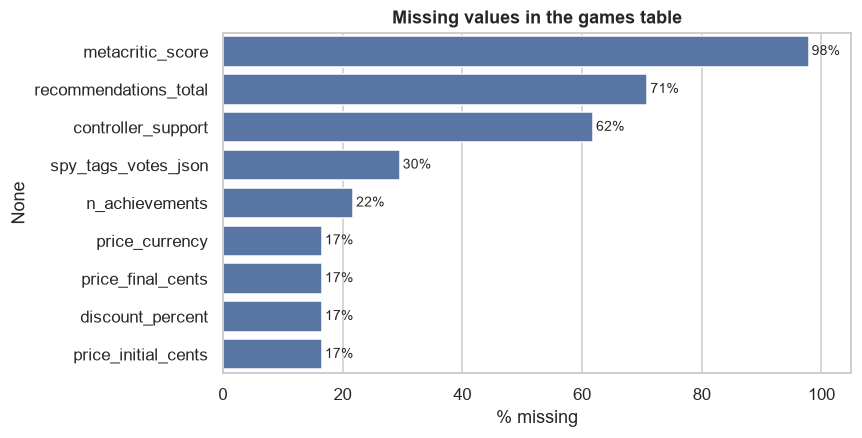

In [4]:
miss = (games.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(8, 0.35 * max(len(miss), 3) + 1))
sns.barplot(x=miss.values, y=miss.index, color=BLUE, ax=ax)
for i, v in enumerate(miss.values):
    ax.text(v + 0.5, i, f"{v:.0f}%", va="center", fontsize=9)
ax.set_xlabel("% missing"); ax.set_xlim(0, 105); ax.set_title("Missing values in the games table")
save("missing_values_games", "Share of missing values per column in the games table")

Game-level pipeline flags


,games_true,pct
appdetails_ok,1861,100.000
price_missing,0,0.000
spy_missing,0,0.000
launch_before_window,86,4.621
review_scrape_complete,1839,98.818
reviews_capped,5,0.269
coming_soon,0,0.000
is_free,308,16.550


Review-level flags (% of reviews)


,pct_true
playtime_outlier,0.500
no_playtime,0.001
is_prerelease,1.821
low_content,12.662
is_ascii_art,0.300
is_copypasta,0.139
text_mining_ok,36.264


Median per-game coverage of the review history: 100.0%


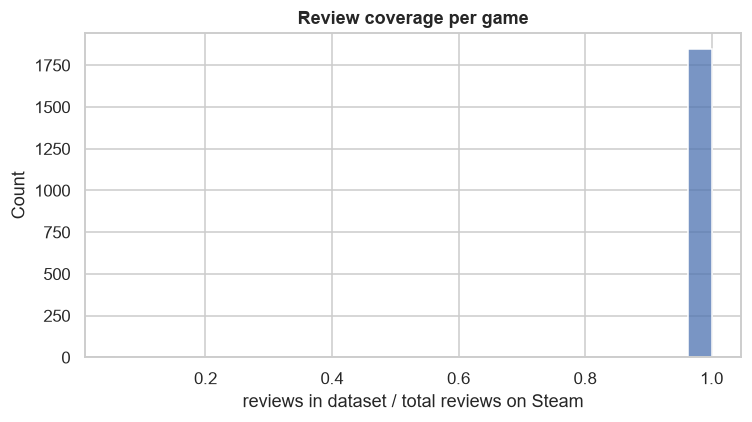

In [5]:
flag_cols = [c for c in ["appdetails_ok", "price_missing", "spy_missing", "launch_before_window",
                         "review_scrape_complete", "reviews_capped", "coming_soon", "is_free"] if c in games.columns]
gflags = games[flag_cols].sum().rename("games_true").to_frame()
gflags["pct"] = gflags.games_true / len(games) * 100
print("Game-level pipeline flags"); display(gflags)

rflags = ["playtime_outlier", "no_playtime", "is_prerelease", "low_content", "is_ascii_art", "is_copypasta", "text_mining_ok"]
print("Review-level flags (% of reviews)"); display((reviews[rflags].mean() * 100).rename("pct_true").to_frame())

rv_cnt = reviews.groupby("appid").size().rename("rv_n")
cov = games[["appid", "steam_total_reviews"]].merge(rv_cnt, on="appid", how="left").fillna({"rv_n": 0})
cov["coverage"] = (cov.rv_n / cov.steam_total_reviews.clip(lower=1)).clip(upper=1)
print(f"Median per-game coverage of the review history: {cov.coverage.median():.1%}")

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(cov.coverage, bins=25, color=BLUE, ax=ax)
ax.set_xlabel("reviews in dataset / total reviews on Steam"); ax.set_title("Review coverage per game")
save("review_coverage", "Share of each game's total review history present in the reviews table")

## 3. Target definition
The modelling target is **negative-review risk**. For each game the *negative ratio* is `steam_total_negative / steam_total_reviews`. A game is labelled **high risk** when this ratio is at least `HIGH_RISK_THRESHOLD`.

Rate comparisons use the *rate set*: games with at least `MIN_REVIEWS_FOR_RATE` reviews. Ratios from very small review counts are highly variable and would add noise to every comparison.

In [6]:
g = games.copy()
g["neg_ratio"] = np.where(g.steam_total_reviews > 0, g.steam_total_negative / g.steam_total_reviews, np.nan)
g["pos_ratio"] = 1 - g.neg_ratio
g["high_risk"] = (g.neg_ratio >= HIGH_RISK_THRESHOLD).astype(int)
g["log_reviews"] = np.log10(g.steam_total_reviews.clip(lower=1))
g["release_year"] = g.release_date.dt.year
g["price_eff"] = np.where(g.is_free, 0.0, g.price_usd)
g["price_band"] = pd.cut(g.price_eff, bins=[-0.01, 0, 5, 10, 15, 20, np.inf],
                         labels=["Free", "$0-5", "$5-10", "$10-15", "$15-20", "$20+"])
g["n_platforms"] = g[["platform_windows", "platform_mac", "platform_linux"]].sum(axis=1)
g["tag_count"] = g.tags.fillna("").str.count(";") + 1
g["genre_count"] = g.genres.fillna("").str.count(";") + 1
g["desc_len"] = g.short_description.fillna("").str.len()
g["has_controller"] = g.controller_support.notna()
g["owners_high_log"] = np.log10(g.spy_owners_high.clip(lower=1))

gr = g[g.steam_total_reviews >= MIN_REVIEWS_FOR_RATE].copy()
OVERALL_RISK = gr.high_risk.mean()
print(f"Rate set: {len(gr)} of {len(g)} games (>= {MIN_REVIEWS_FOR_RATE} reviews)")
print(f"High-risk share: {OVERALL_RISK:.1%} ({int(gr.high_risk.sum())} games) | median negative ratio: {gr.neg_ratio.median():.1%}")

consistency = (g.search_pct_positive / 100 - g.pos_ratio).abs()
print(f"Consistency check, |search_pct_positive - computed positive ratio|: median {consistency.median():.3f}, 95th percentile {consistency.quantile(.95):.3f}")

Rate set: 1490 of 1861 games (>= 20 reviews)
High-risk share: 14.5% (216 games) | median negative ratio: 14.3%
Consistency check, |search_pct_positive - computed positive ratio|: median 0.010, 95th percentile 0.076


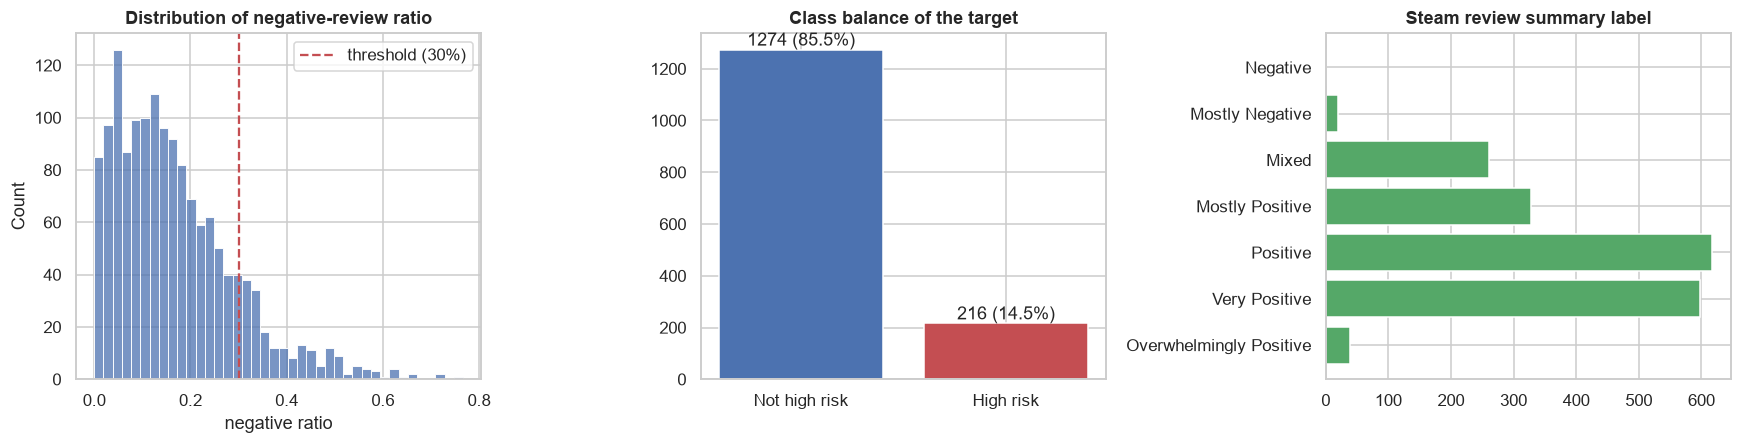

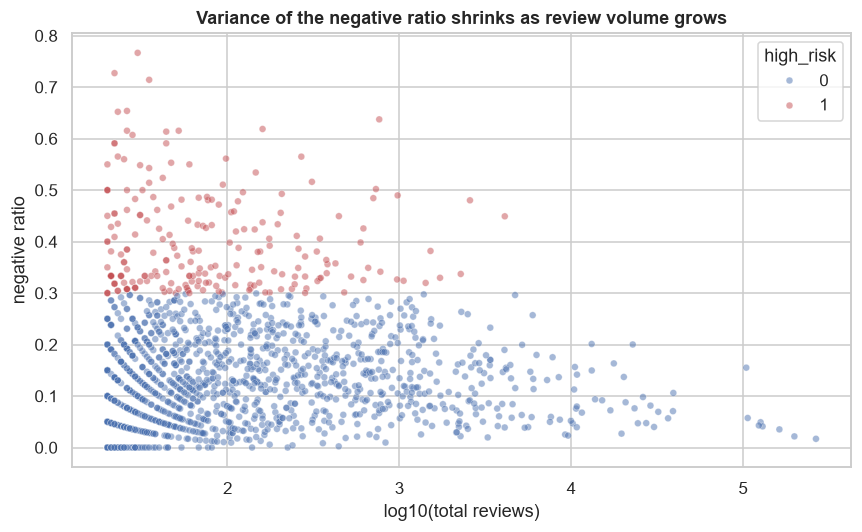

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
sns.histplot(gr.neg_ratio, bins=40, color=BLUE, ax=axes[0])
axes[0].axvline(HIGH_RISK_THRESHOLD, color=RED, ls="--", label=f"threshold ({HIGH_RISK_THRESHOLD:.0%})")
axes[0].set_title("Distribution of negative-review ratio"); axes[0].set_xlabel("negative ratio"); axes[0].legend()

cls = gr.high_risk.map({0: "Not high risk", 1: "High risk"}).value_counts().reindex(["Not high risk", "High risk"])
axes[1].bar(cls.index, cls.values, color=[BLUE, RED])
for i, v in enumerate(cls.values):
    axes[1].text(i, v, f"{v} ({v / len(gr):.1%})", ha="center", va="bottom")
axes[1].set_title("Class balance of the target")

order = ["Overwhelmingly Negative", "Very Negative", "Negative", "Mostly Negative", "Mixed", "Mostly Positive",
         "Positive", "Very Positive", "Overwhelmingly Positive"]
sd = g.steam_review_score_desc.value_counts()
sd = sd.reindex([o for o in order if o in sd.index] + [o for o in sd.index if o not in order])
axes[2].barh(sd.index[::-1], sd.values[::-1], color=GREEN); axes[2].set_title("Steam review summary label")
save("target_definition", "Negative-ratio distribution, target class balance and Steam review label counts")

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=gr, x="log_reviews", y="neg_ratio", hue="high_risk", palette={0: BLUE, 1: RED}, alpha=0.5, s=20, ax=ax)
ax.set_xlabel("log10(total reviews)"); ax.set_ylabel("negative ratio")
ax.set_title("Variance of the negative ratio shrinks as review volume grows")
save("negative_ratio_vs_review_volume", "Negative ratio against review volume (funnel shape shows small-sample noise)")

## 4. Univariate analysis

n_achievements is missing for 405 games (22%); these are excluded from the achievements histogram.


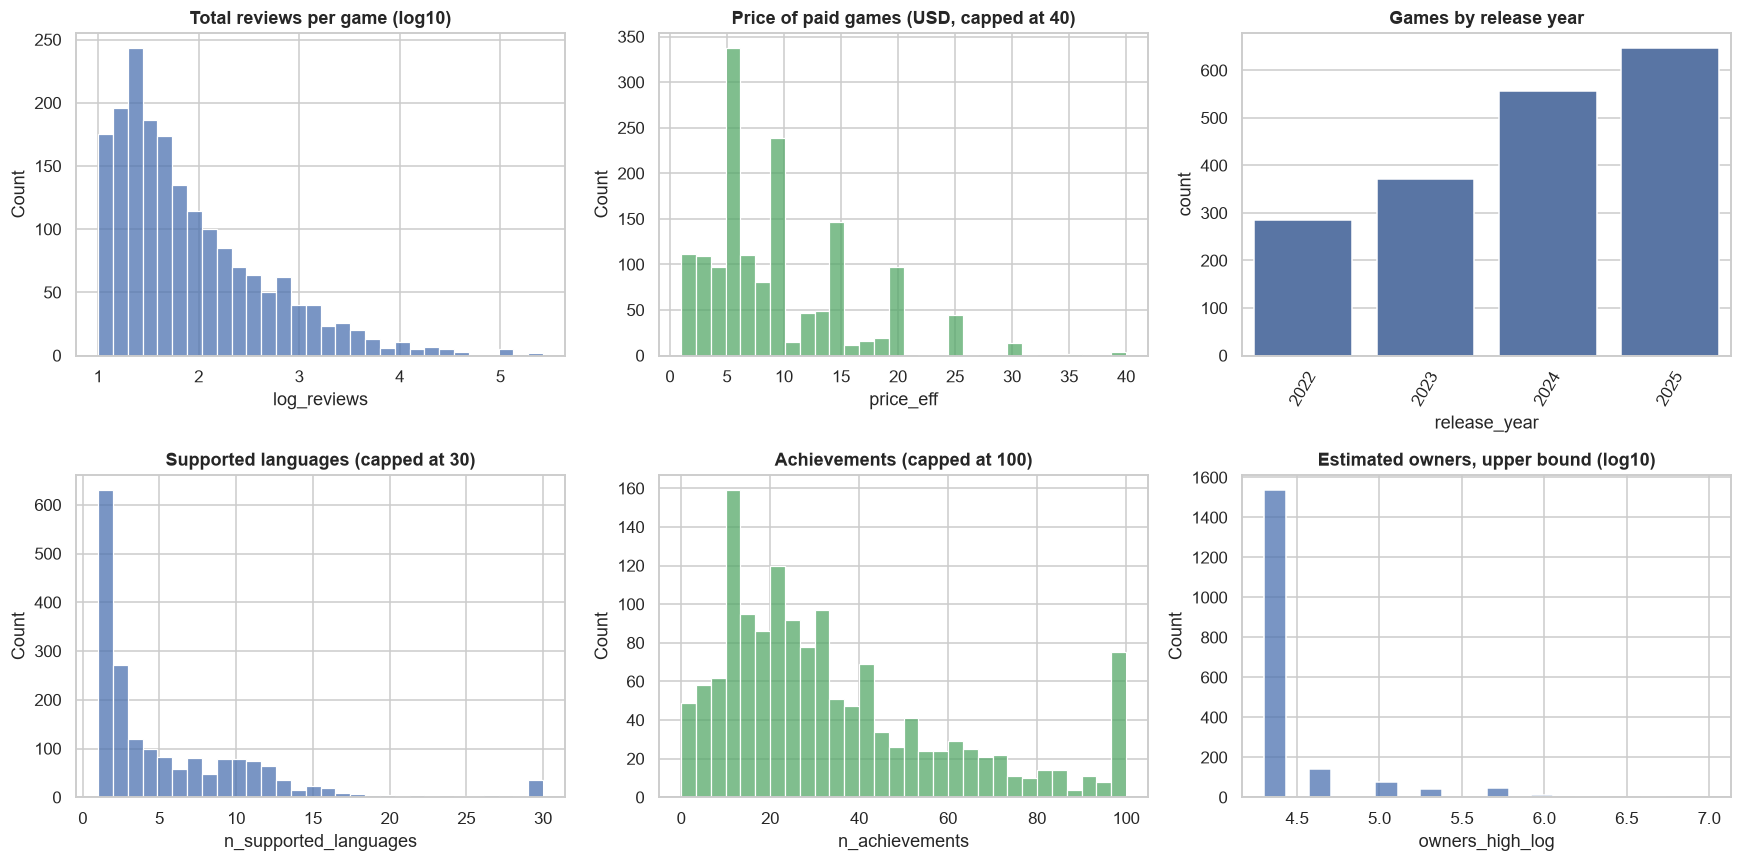

In [8]:
n_ach_missing = int(g.n_achievements.isna().sum())
print(f"n_achievements is missing for {n_ach_missing} games ({n_ach_missing / len(g):.0%}); these are excluded from the achievements histogram.")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
sns.histplot(g.log_reviews, bins=30, color=BLUE, ax=axes[0, 0]); axes[0, 0].set_title("Total reviews per game (log10)")
paid = g[(~g.is_free) & g.price_eff.notna()]
sns.histplot(paid.price_eff.clip(upper=40), bins=30, color=GREEN, ax=axes[0, 1]); axes[0, 1].set_title("Price of paid games (USD, capped at 40)")
sns.countplot(data=g, x="release_year", color=BLUE, ax=axes[0, 2]); axes[0, 2].set_title("Games by release year"); axes[0, 2].tick_params(axis="x", rotation=60)
sns.histplot(g.n_supported_languages.dropna().clip(upper=30), bins=30, color=BLUE, ax=axes[1, 0]); axes[1, 0].set_title("Supported languages (capped at 30)")
sns.histplot(g.n_achievements.dropna().clip(upper=100), bins=30, color=GREEN, ax=axes[1, 1]); axes[1, 1].set_title("Achievements (capped at 100)")
sns.histplot(g.owners_high_log, bins=20, color=BLUE, ax=axes[1, 2]); axes[1, 2].set_title("Estimated owners, upper bound (log10)")
save("univariate_numeric", "Distributions of review volume, price, release year, languages, achievements and owner estimate")

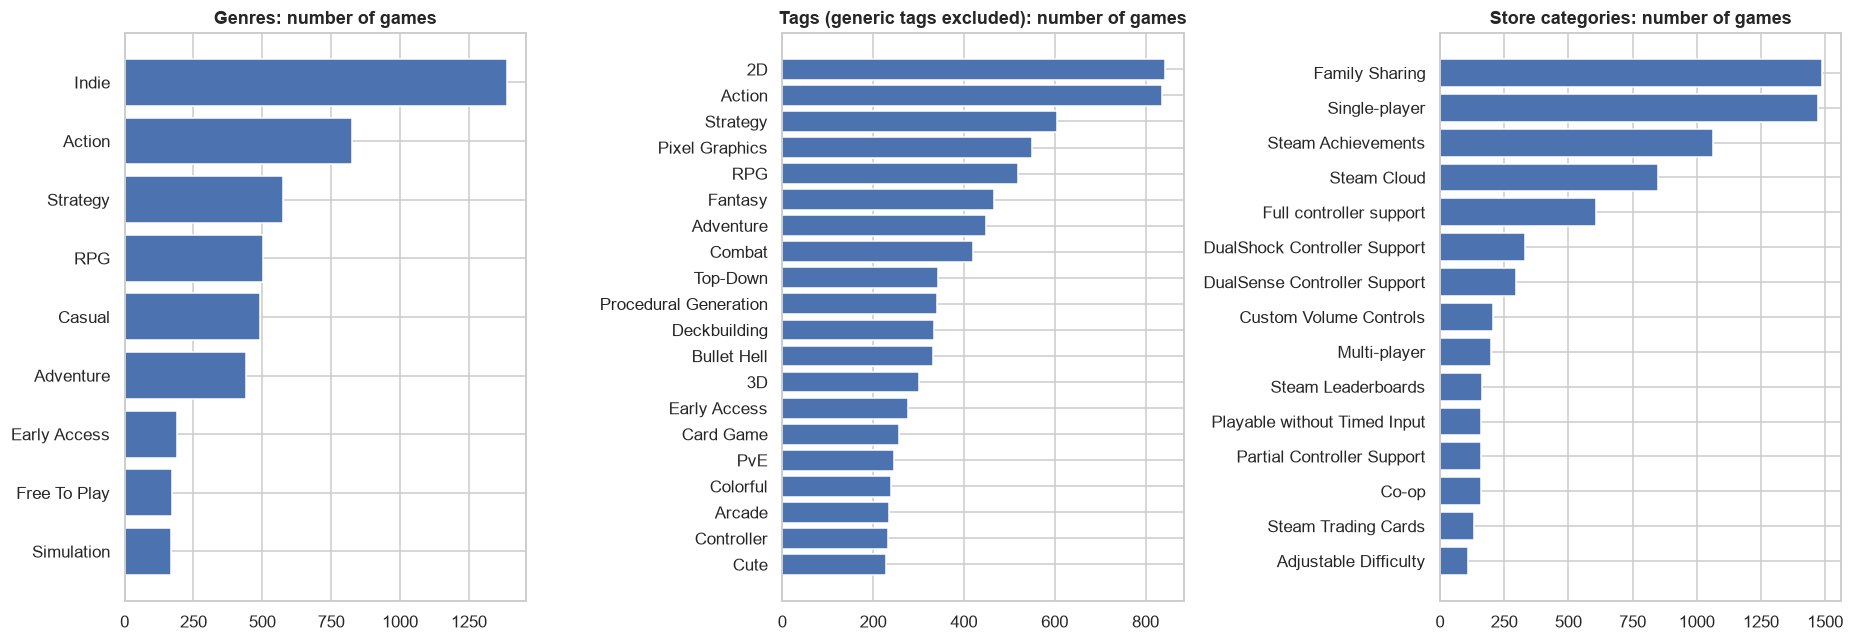

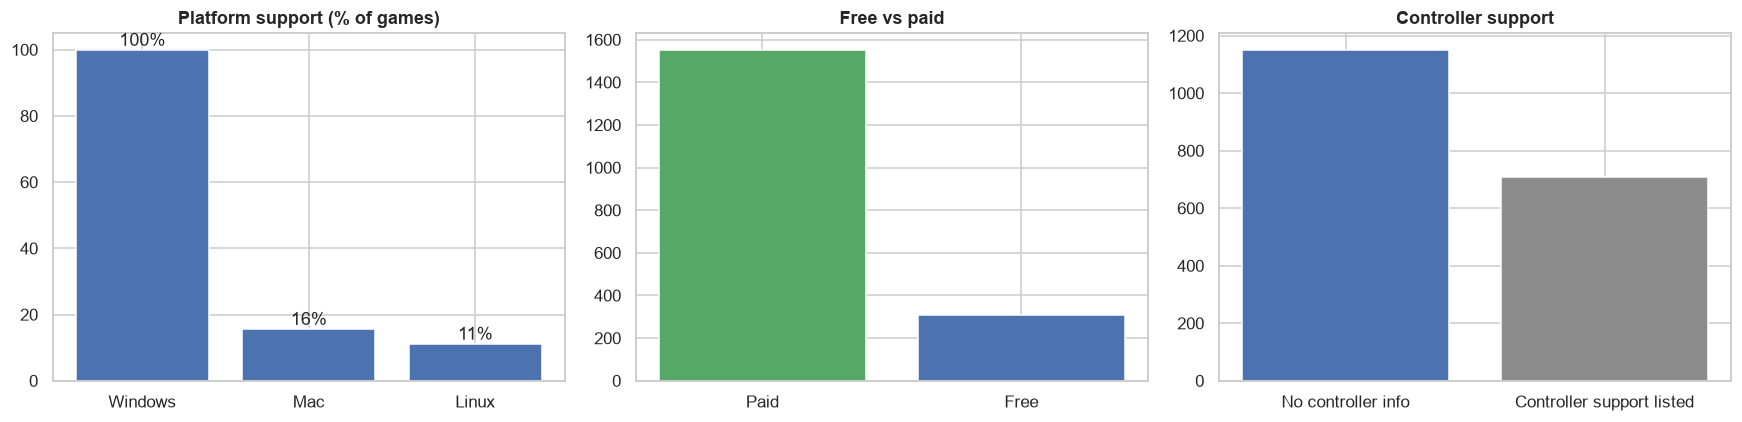

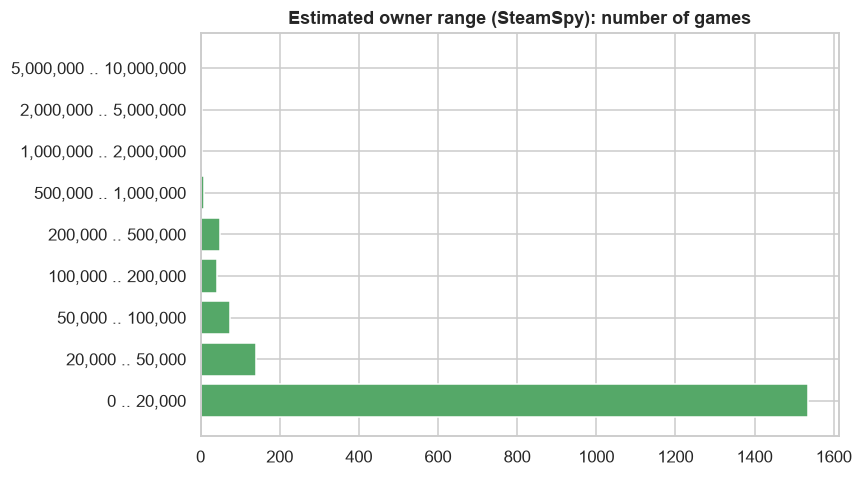

1930 distinct developers; 95% have exactly one game in the dataset


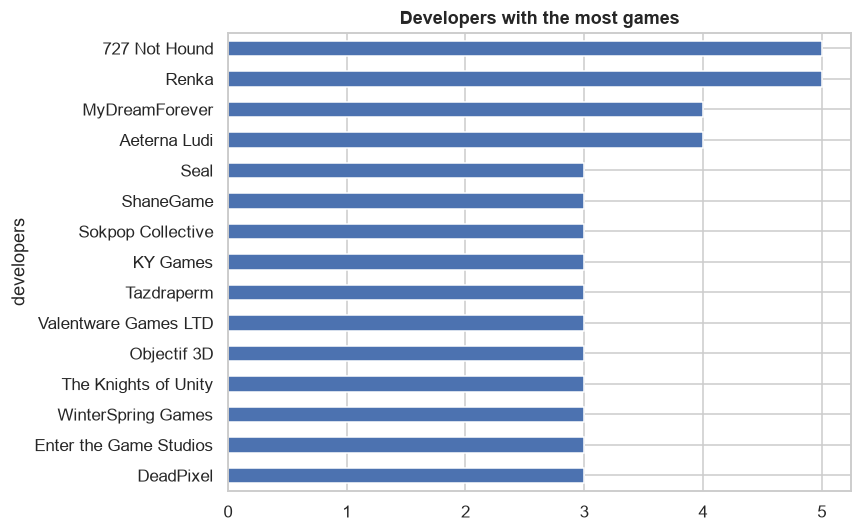

In [9]:
def label_stats(df, col, sep=";", min_n=20):
    """Per-label game count and risk statistics for a delimiter-separated multi-label column."""
    t = df.assign(label=df[col].fillna("").str.split(sep)).explode("label")
    t["label"] = t["label"].str.strip()
    t = t[t["label"] != ""]
    out = t.groupby("label").agg(n=("appid", "nunique"), k=("high_risk", "sum"), risk=("high_risk", "mean"),
                                 mean_neg=("neg_ratio", "mean"), median_reviews=("steam_total_reviews", "median"))
    return out[out.n >= min_n].sort_values("n", ascending=False)

genre_stats = label_stats(gr, "genres")
tag_stats = label_stats(gr, "tags")
tag_stats = tag_stats.drop(index=[t for t in GENERIC_TAGS if t in tag_stats.index])
cat_stats = label_stats(gr, "categories")

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
for ax, st, title in zip(axes, [genre_stats.head(15), tag_stats.head(20), cat_stats.head(15)],
                         ["Genres", "Tags (generic tags excluded)", "Store categories"]):
    ax.barh(st.index[::-1], st.n.values[::-1], color=BLUE); ax.set_title(f"{title}: number of games")
save("univariate_genres_tags_categories", "Most frequent genres, tags and store categories")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plat = g[["platform_windows", "platform_mac", "platform_linux"]].mean() * 100
axes[0].bar(["Windows", "Mac", "Linux"], plat.values, color=BLUE); axes[0].set_title("Platform support (% of games)")
for i, v in enumerate(plat.values): axes[0].text(i, v, f"{v:.0f}%", ha="center", va="bottom")
fp = g.is_free.map({True: "Free", False: "Paid"}).value_counts()
axes[1].bar(fp.index, fp.values, color=[GREEN, BLUE][: len(fp)]); axes[1].set_title("Free vs paid")
ctrl = g.has_controller.map({True: "Controller support listed", False: "No controller info"}).value_counts()
axes[2].bar(ctrl.index, ctrl.values, color=[BLUE, GREY][: len(ctrl)]); axes[2].set_title("Controller support")
save("univariate_platform_price_controller", "Platform support, free versus paid, and controller support")

own_n = g.groupby("spy_owners_raw").agg(n=("appid", "size"), hi=("spy_owners_high", "first")).sort_values("hi")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(own_n.index, own_n.n, color=GREEN); ax.set_title("Estimated owner range (SteamSpy): number of games")
save("univariate_owner_ranges", "Number of games per estimated owner range")

dev = g.developers.fillna("").str.split(";").explode().str.strip()
dev = dev[dev != ""].value_counts()
print(f"{dev.shape[0]} distinct developers; {(dev == 1).mean():.0%} have exactly one game in the dataset")
fig, ax = plt.subplots(figsize=(8, 5))
dev.head(15)[::-1].plot.barh(color=BLUE, ax=ax); ax.set_title("Developers with the most games")
save("top_developers", "Developers with the most games in the dataset")

## 5. Bivariate analysis (game level)
Bars show the **high-risk rate** (share of games at or above the threshold) with Wilson 95% confidence intervals; `n` is the number of games per bar and the dashed line is the overall rate. Where intervals overlap the dashed line, the difference from the overall rate is not distinguishable from sampling variation.

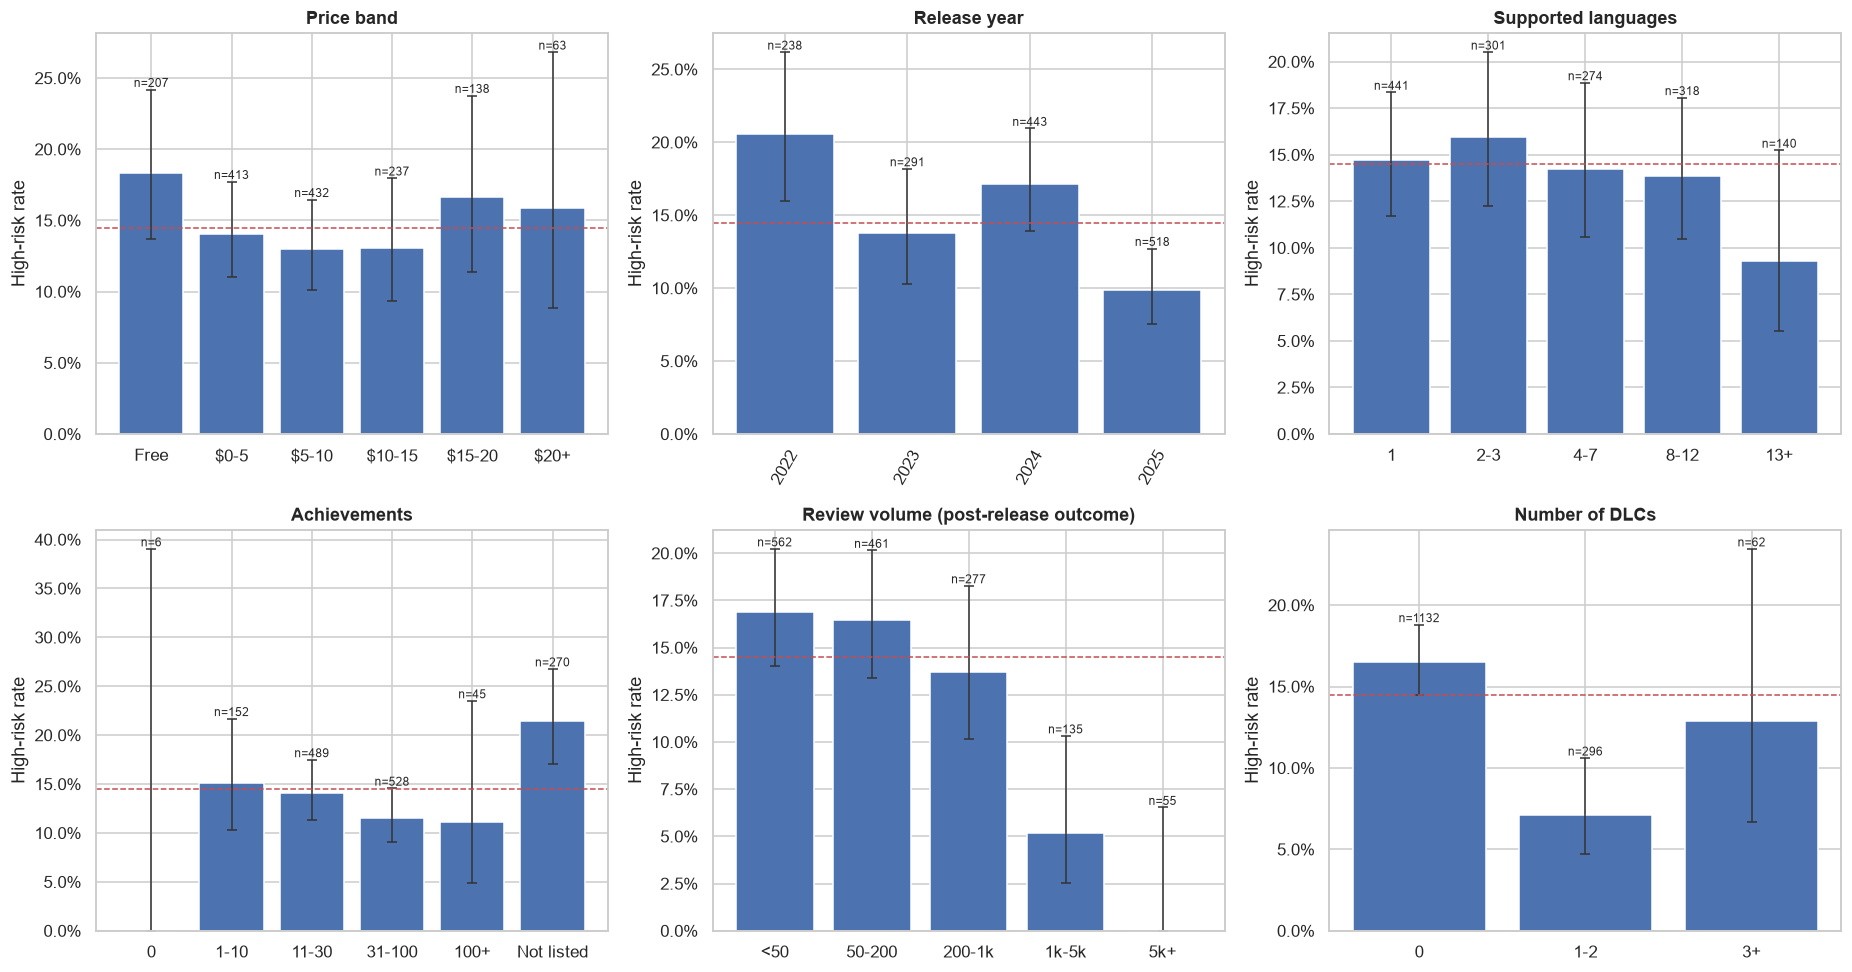

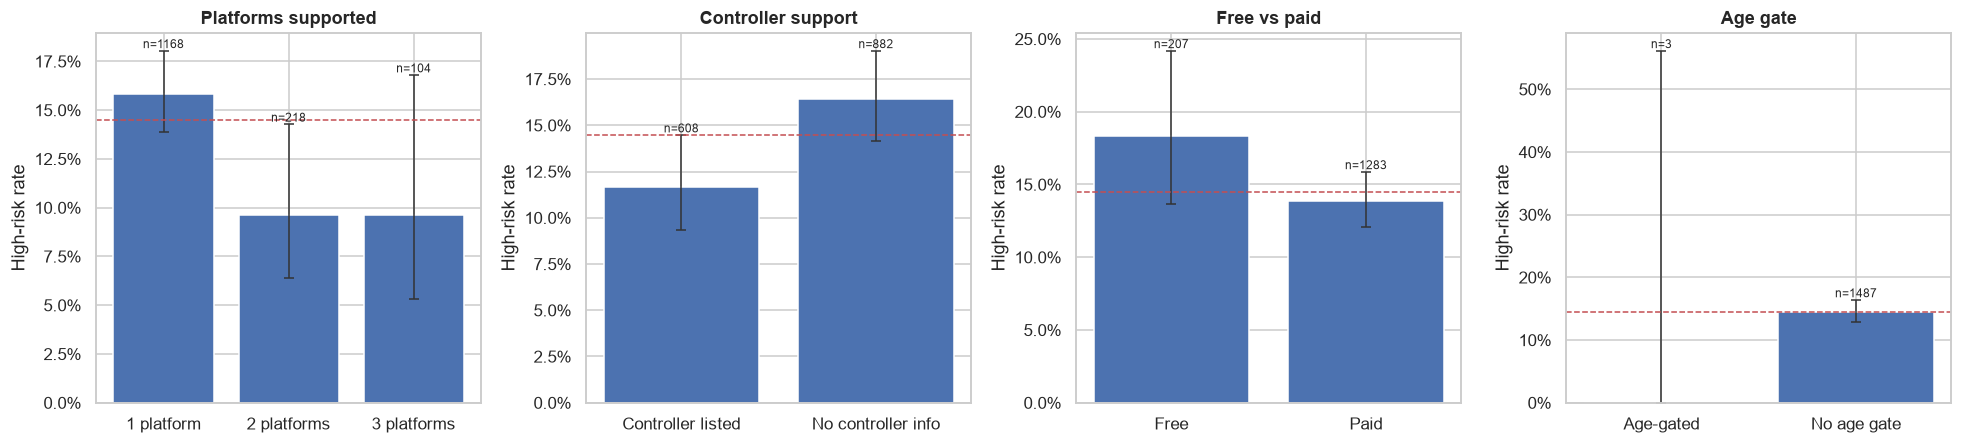

In [10]:
def risk_by(df, col, ax, title, rot=0):
    t = (df.groupby(col, observed=True)
           .agg(n=("appid", "size"), k=("high_risk", "sum"), risk=("high_risk", "mean")).reset_index())
    lo, hi = wilson(t.k, t.n)
    ax.bar(range(len(t)), t.risk, color=BLUE, yerr=err(t.risk, lo, hi),
           capsize=3, error_kw={"elinewidth": 1, "ecolor": "#333333"})
    ax.axhline(OVERALL_RISK, ls="--", c=RED, lw=1)
    for i, (h, n) in enumerate(zip(hi, t.n)):
        ax.text(i, h, f"n={int(n)}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(range(len(t))); ax.set_xticklabels(t[col].astype(str), rotation=rot)
    ax.set_title(title); ax.set_ylabel("High-risk rate"); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    return t

gr["lang_band"] = binned(gr.n_supported_languages, [0, 1, 3, 7, 12, 100], ["1", "2-3", "4-7", "8-12", "13+"])
gr["ach_band"] = binned(gr.n_achievements, [-1, 0, 10, 30, 100, 1e5], ["0", "1-10", "11-30", "31-100", "100+"])
gr["ach_band"] = gr["ach_band"].cat.add_categories("Not listed").fillna("Not listed")
gr["review_band"] = binned(gr.steam_total_reviews, [0, 50, 200, 1000, 5000, 1e9], ["<50", "50-200", "200-1k", "1k-5k", "5k+"])
gr["dlc_band"] = binned(gr.n_dlc, [-1, 0, 2, 100], ["0", "1-2", "3+"])
gr["os_band"] = gr.n_platforms.astype(int).map({0: "none", 1: "1 platform", 2: "2 platforms", 3: "3 platforms"})
gr["ctrl"] = gr.has_controller.map({True: "Controller listed", False: "No controller info"})
gr["free"] = gr.is_free.map({True: "Free", False: "Paid"})
gr["age_gate"] = np.where(gr.required_age.fillna(0) > 0, "Age-gated", "No age gate")

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
risk_by(gr, "price_band", axes[0, 0], "Price band")
risk_by(gr, "release_year", axes[0, 1], "Release year", rot=60)
risk_by(gr, "lang_band", axes[0, 2], "Supported languages")
risk_by(gr, "ach_band", axes[1, 0], "Achievements")
risk_by(gr, "review_band", axes[1, 1], "Review volume (post-release outcome)")
risk_by(gr, "dlc_band", axes[1, 2], "Number of DLCs")
save("risk_by_game_features", "High-risk rate by price, release year, languages, achievements, review volume and DLC count")

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
risk_by(gr, "os_band", axes[0], "Platforms supported")
risk_by(gr, "ctrl", axes[1], "Controller support")
risk_by(gr, "free", axes[2], "Free vs paid")
risk_by(gr, "age_gate", axes[3], "Age gate")
save("risk_by_platform_controller_free", "High-risk rate by platform count, controller support, free versus paid and age gate")

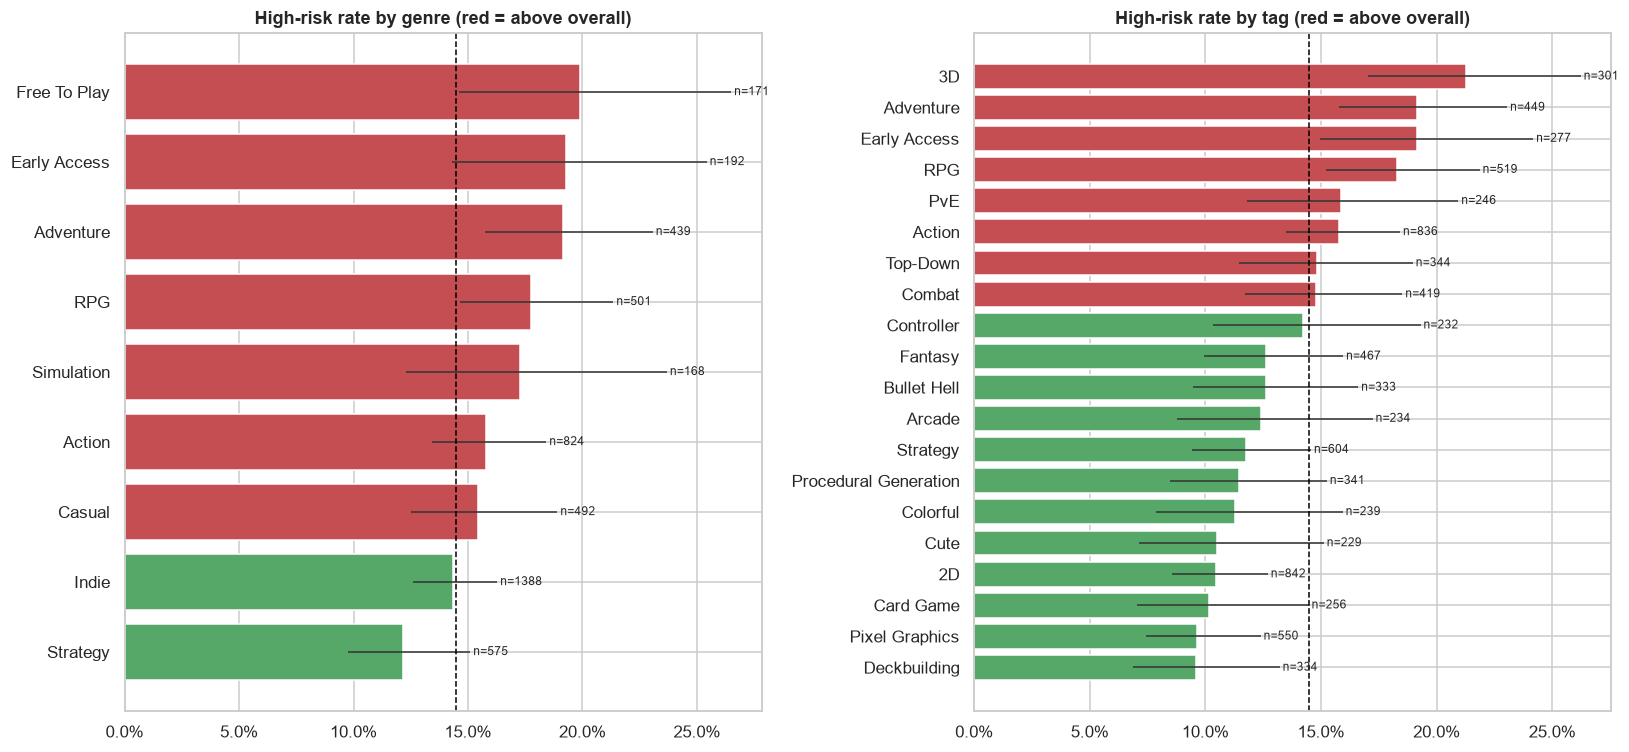

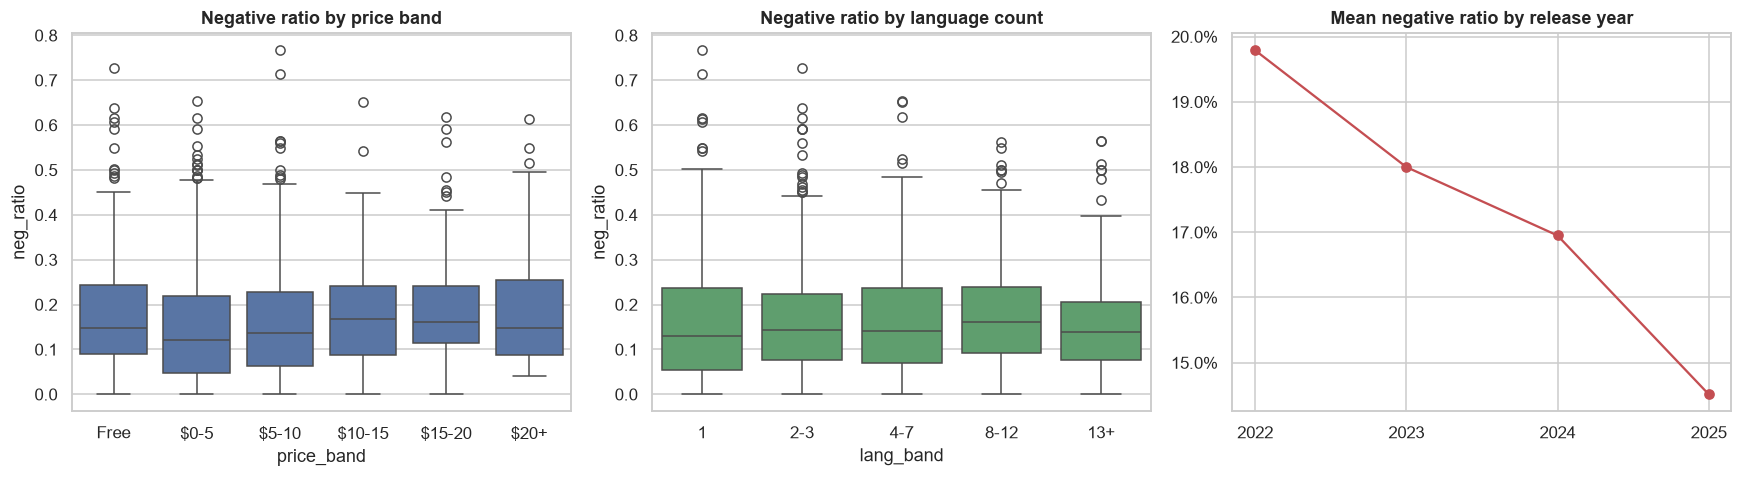

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, st, title in zip(axes, [genre_stats.head(15), tag_stats.head(20)], ["genre", "tag"]):
    s = st.sort_values("risk")
    lo, hi = wilson(s.k, s.n)
    ax.barh(s.index, s.risk, color=[RED if r > OVERALL_RISK else GREEN for r in s.risk],
            xerr=err(s.risk, lo, hi), error_kw={"elinewidth": 1, "ecolor": "#333333"})
    ax.axvline(OVERALL_RISK, ls="--", c="black", lw=1)
    for i, (h, n) in enumerate(zip(hi, s.n)):
        ax.text(h, i, f" n={int(n)}", va="center", fontsize=8)
    ax.set_title(f"High-risk rate by {title} (red = above overall)"); ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
save("risk_by_genre_and_tag", "High-risk rate by genre and by tag with 95% intervals")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(data=gr, x="price_band", y="neg_ratio", color=BLUE, ax=axes[0]); axes[0].set_title("Negative ratio by price band")
sns.boxplot(data=gr, x="lang_band", y="neg_ratio", color=GREEN, ax=axes[1]); axes[1].set_title("Negative ratio by language count")
gy = gr.groupby("release_year").agg(neg=("neg_ratio", "mean"), n=("appid", "size")).reset_index()
axes[2].plot(gy.release_year, gy.neg, marker="o", color=RED); axes[2].set_xticks(gy.release_year)
axes[2].set_title("Mean negative ratio by release year"); axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
save("negative_ratio_distributions", "Distribution of the negative ratio by price band and language count, and yearly mean")

## 6. Review-level analysis
Each row is one review; `voted_up` is True for a positive recommendation. Playtime is converted from minutes to hours on the assumption that Steam reports minutes (confirm against `docs/data_documentation.md`).

Negative share across all reviews: 10.4%


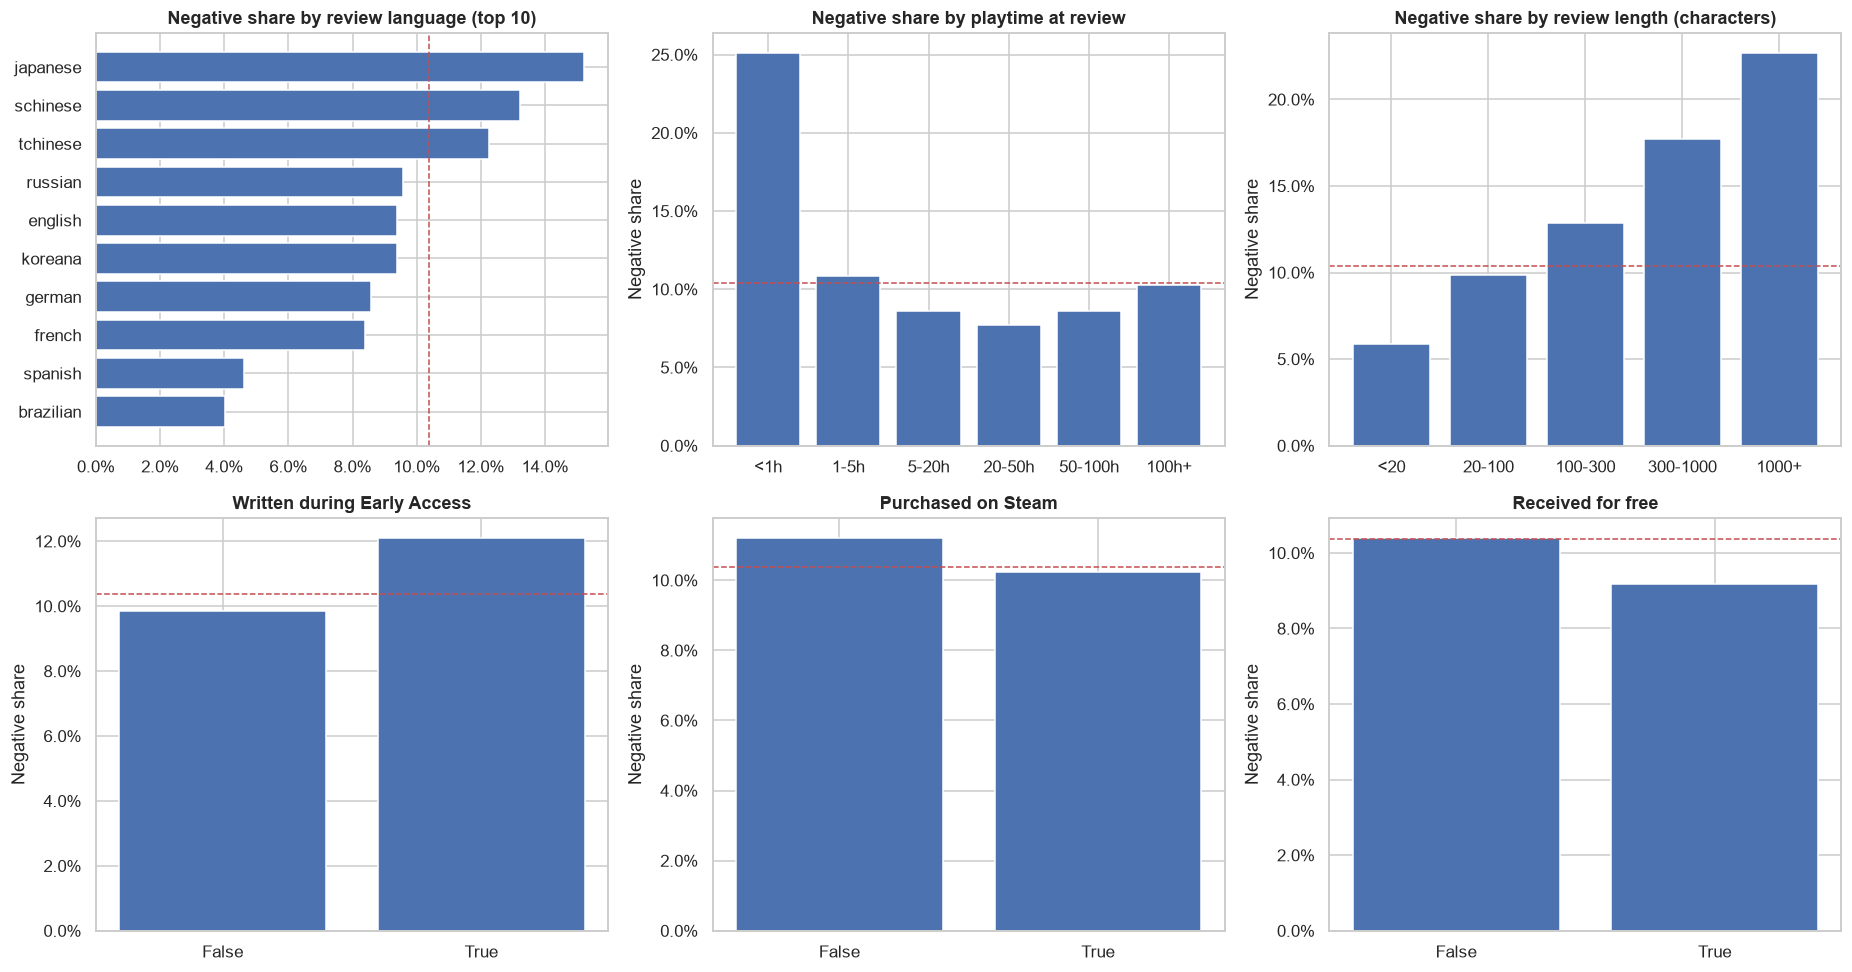

In [12]:
reviews["neg"] = (~reviews.voted_up).astype(int)
reviews["hours_at_review"] = reviews.author_playtime_at_review / 60
REV_NEG = reviews.neg.mean()
print(f"Negative share across all reviews: {REV_NEG:.1%}")

def neg_by(col, ax, title, rot=0, min_n=1000):
    t = reviews.groupby(col, observed=True).agg(n=("neg", "size"), neg=("neg", "mean")).reset_index()
    t = t[t.n >= min_n]
    ax.bar(t[col].astype(str), t.neg, color=BLUE)
    ax.axhline(REV_NEG, ls="--", c=RED, lw=1)
    ax.set_title(title); ax.set_ylabel("Negative share"); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.tick_params(axis="x", rotation=rot)
    return t

reviews["playtime_band"] = binned(reviews.hours_at_review, [0, 1, 5, 20, 50, 100, 1e9], ["<1h", "1-5h", "5-20h", "20-50h", "50-100h", "100h+"])
reviews["len_band"] = binned(reviews.review_len, [-1, 20, 100, 300, 1000, 1e9], ["<20", "20-100", "100-300", "300-1000", "1000+"])
top_lang = reviews.language.value_counts().head(10).index
rl = reviews[reviews.language.isin(top_lang)]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
t = rl.groupby("language").neg.mean().sort_values()
axes[0, 0].barh(t.index, t.values, color=BLUE); axes[0, 0].set_title("Negative share by review language (top 10)")
axes[0, 0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0)); axes[0, 0].axvline(REV_NEG, ls="--", c=RED, lw=1)
playtime_tbl = neg_by("playtime_band", axes[0, 1], "Negative share by playtime at review")
len_tbl = neg_by("len_band", axes[0, 2], "Negative share by review length (characters)")
ea_tbl = neg_by("written_during_early_access", axes[1, 0], "Written during Early Access")
neg_by("steam_purchase", axes[1, 1], "Purchased on Steam")
neg_by("received_for_free", axes[1, 2], "Received for free")
save("review_level_negative_share", "Negative share of reviews by language, playtime, length, Early Access, purchase type and free copies")

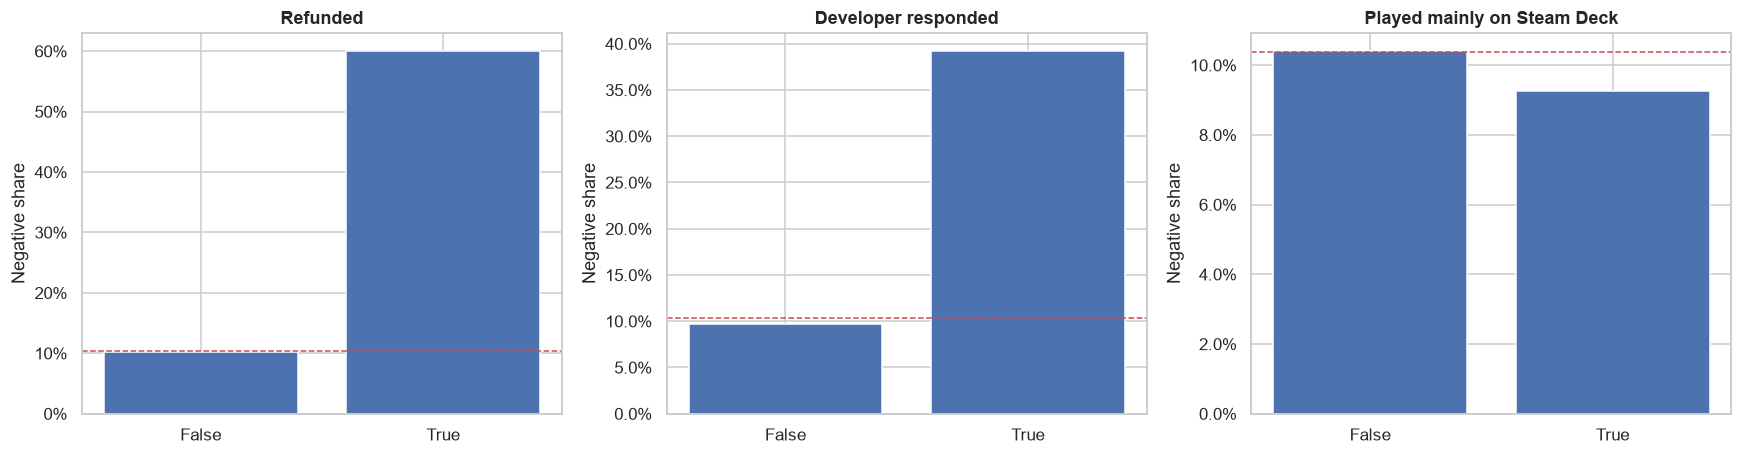

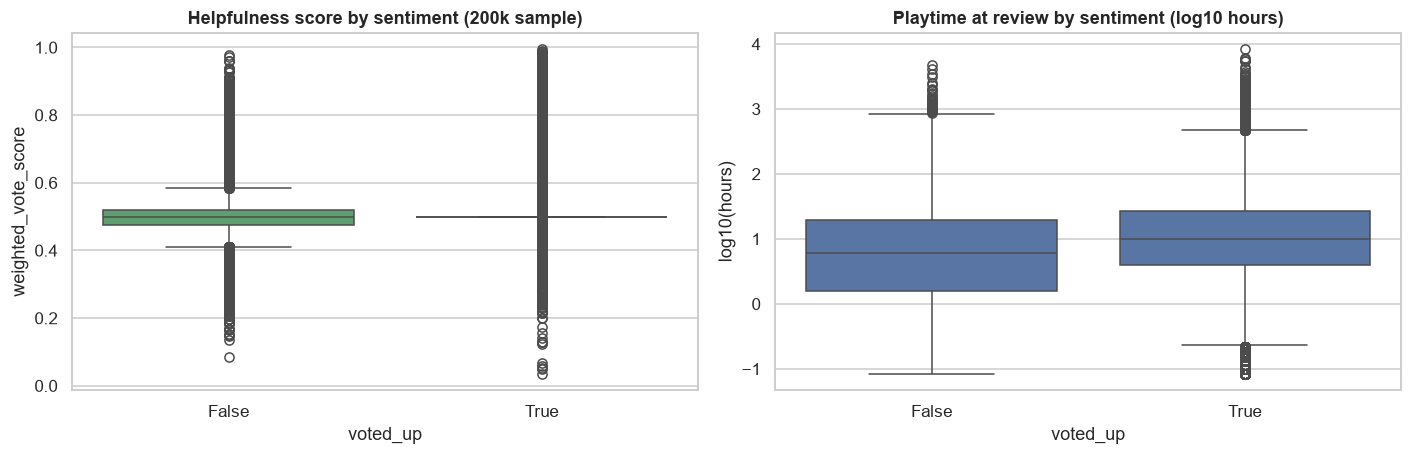

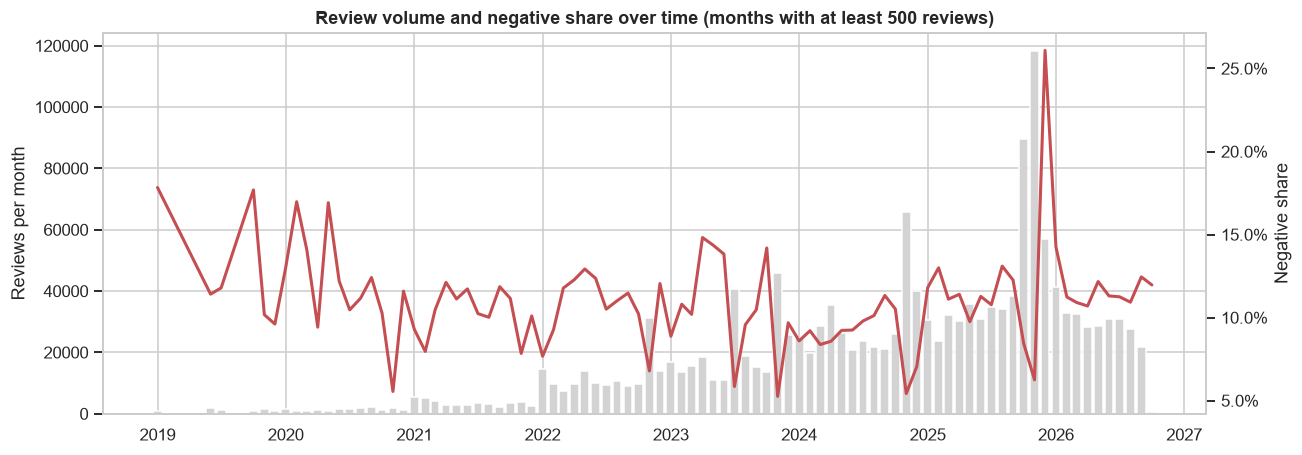

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
neg_by("refunded", axes[0], "Refunded", min_n=100)
neg_by("has_dev_response", axes[1], "Developer responded", min_n=100)
neg_by("primarily_steam_deck", axes[2], "Played mainly on Steam Deck", min_n=100)
save("review_level_flags", "Negative share of reviews by refund, developer response and Steam Deck flags")

sample = reviews.sample(min(200_000, len(reviews)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
sns.boxplot(data=sample, x="voted_up", y="weighted_vote_score", color=GREEN, ax=axes[0]); axes[0].set_title("Helpfulness score by sentiment (200k sample)")
sns.boxplot(x=sample.voted_up, y=np.log10(sample.hours_at_review.clip(lower=0.01)), color=BLUE, ax=axes[1])
axes[1].set_title("Playtime at review by sentiment (log10 hours)"); axes[1].set_ylabel("log10(hours)")
save("helpfulness_and_playtime_by_sentiment", "Helpfulness score and playtime at review by review sentiment (200k sample)")

reviews["month"] = naive(reviews.created).dt.to_period("M").dt.to_timestamp()
mt = reviews.groupby("month").agg(n=("neg", "size"), neg=("neg", "mean")).reset_index()
mt = mt[mt.n >= 500]
fig, ax1 = plt.subplots(figsize=(12, 4.3))
ax1.bar(mt.month, mt.n, width=25, color="lightgrey"); ax1.set_ylabel("Reviews per month")
ax2 = ax1.twinx(); ax2.plot(mt.month, mt.neg, color=RED, lw=2); ax2.set_ylabel("Negative share")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax2.grid(False)
ax1.set_title("Review volume and negative share over time (months with at least 500 reviews)")
save("monthly_review_trend", "Monthly review volume and negative share")

Representativeness check: Spearman(scraped negative share, Steam negative ratio) = 1.000


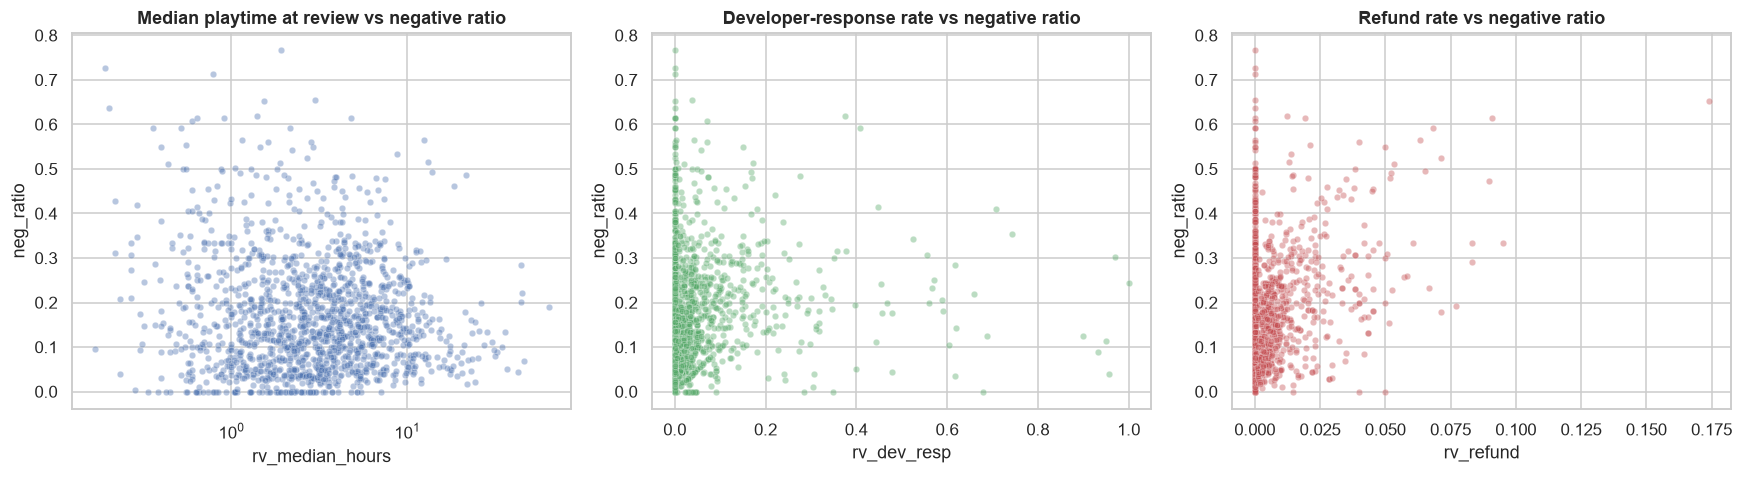

In [14]:
# Game-level aggregates of review behaviour (post-release signals)
rv = reviews.assign(ea=reviews.written_during_early_access.astype(int), dev=reviews.has_dev_response.astype(int),
                    ref=reviews.refunded.astype(int))
rv_game = rv.groupby("appid").agg(rv_n=("neg", "size"), rv_neg_share=("neg", "mean"), rv_ea_share=("ea", "mean"),
                                  rv_dev_resp=("dev", "mean"), rv_refund=("ref", "mean"),
                                  rv_median_hours=("hours_at_review", "median"), rv_median_len=("review_len", "median")).reset_index()
g = g.merge(rv_game, on="appid", how="left")
gr = gr.merge(rv_game, on="appid", how="left")

rho = gr[["rv_neg_share", "neg_ratio"]].corr(method="spearman").iloc[0, 1]
print(f"Representativeness check: Spearman(scraped negative share, Steam negative ratio) = {rho:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.scatterplot(data=gr, x="rv_median_hours", y="neg_ratio", alpha=0.4, s=18, color=BLUE, ax=axes[0]); axes[0].set_xscale("log"); axes[0].set_title("Median playtime at review vs negative ratio")
sns.scatterplot(data=gr, x="rv_dev_resp", y="neg_ratio", alpha=0.4, s=18, color=GREEN, ax=axes[1]); axes[1].set_title("Developer-response rate vs negative ratio")
sns.scatterplot(data=gr, x="rv_refund", y="neg_ratio", alpha=0.4, s=18, color=RED, ax=axes[2]); axes[2].set_title("Refund rate vs negative ratio")
save("game_level_review_aggregates", "Game-level review aggregates (playtime, developer response, refunds) against negative ratio")

## 7. Post-release activity
`events` contains news and update posts per game, typed as `patch` or `sale`. Post counts are compared with risk overall and within the first 90 days after the store release date.

Median posts per game (games with at least one): 9.0


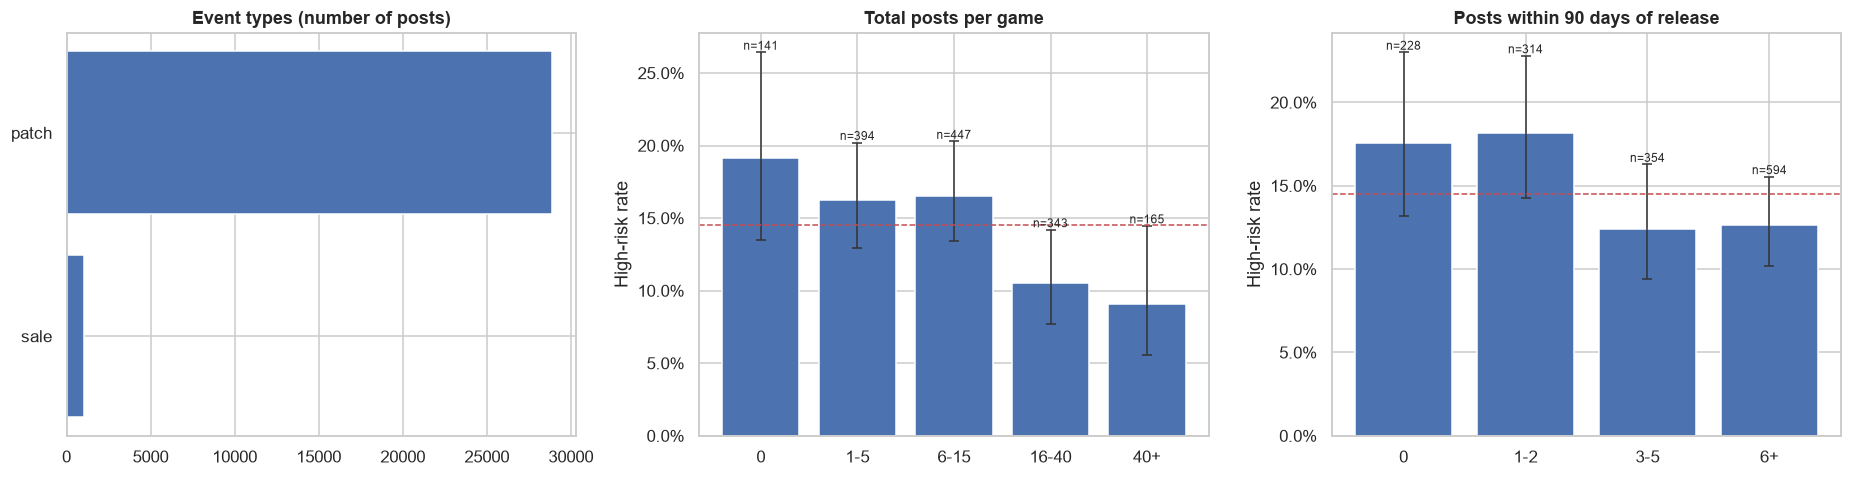

In [15]:
ev = events.copy()
ev["date_n"] = naive(ev.date)
ev = ev.merge(g[["appid", "release_date"]], on="appid", how="left")
ev["days_since_release"] = (ev.date_n - ev.release_date).dt.days

type_counts = ev.event_type.value_counts()
print("Median posts per game (games with at least one):", ev.groupby("appid").size().median())
ev_game = ev.groupby("appid").agg(ev_n=("gid", "size"), ev_patch=("event_type", lambda s: (s == "patch").sum())).reset_index()
first90 = ev[(ev.days_since_release >= 0) & (ev.days_since_release <= 90)].groupby("appid").size().rename("ev_first90").reset_index()
g = g.merge(ev_game, on="appid", how="left").merge(first90, on="appid", how="left")
gr = gr.merge(ev_game, on="appid", how="left").merge(first90, on="appid", how="left")
for c in ["ev_n", "ev_patch", "ev_first90"]:
    g[c] = g[c].fillna(0); gr[c] = gr[c].fillna(0)

gr["ev_band"] = binned(gr.ev_n, [-1, 0, 5, 15, 40, 1e6], ["0", "1-5", "6-15", "16-40", "40+"])
gr["ev90_band"] = binned(gr.ev_first90, [-1, 0, 2, 5, 1e6], ["0", "1-2", "3-5", "6+"])

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
axes[0].barh(type_counts.index[::-1], type_counts.values[::-1], color=BLUE); axes[0].set_title("Event types (number of posts)")
risk_by(gr, "ev_band", axes[1], "Total posts per game")
risk_by(gr, "ev90_band", axes[2], "Posts within 90 days of release")
save("events_and_risk", "Event type counts and high-risk rate by number of posts overall and in the first 90 days")

## 8. Association tests
Chi-square tests of independence between each banded feature and the high-risk label. Cramer's V expresses effect size (0 = no association, 1 = perfect association); with this sample size, statistically significant results can still be practically small.

,feature,levels,chi2,dof,p_value,cramers_v,q_value,significant_fdr
0,Review volume (post-release),5,23.003,4,0.000,0.124,0.001,True
1,DLC count,3,16.948,2,0.000,0.107,0.001,True
2,Release year,4,18.825,3,0.000,0.112,0.001,True
3,Achievements,6,15.860,5,0.007,0.103,0.022,True
4,Posts per game (post-release),5,13.280,4,0.010,0.094,0.024,True
5,Controller support,2,6.207,1,0.013,0.065,0.025,True
6,Platforms,3,7.858,2,0.020,0.073,0.034,True
7,Posts in first 90 days (post-release),4,7.991,3,0.046,0.073,0.069,False
8,Free vs paid,2,2.541,1,0.111,0.041,0.148,False
9,Supported languages,5,3.673,4,0.452,0.050,0.541,False


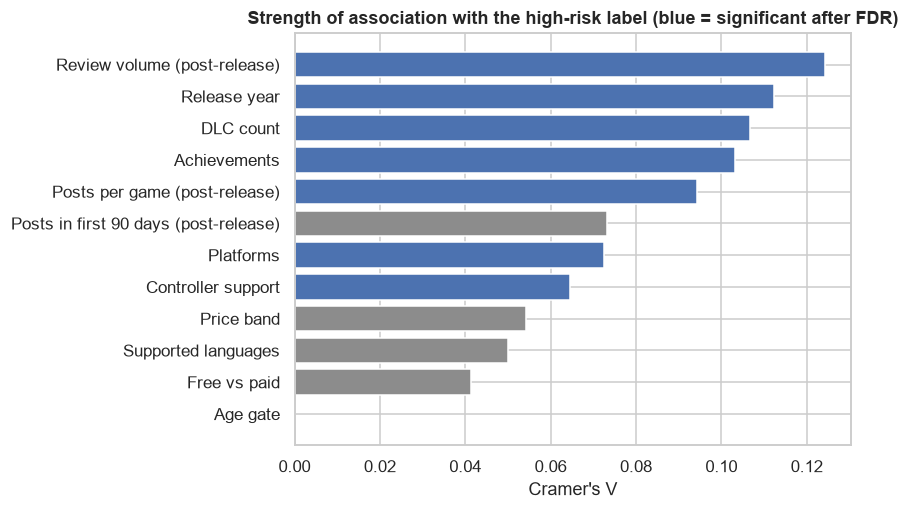

In [16]:
test_vars = {"price_band": "Price band", "release_year": "Release year", "lang_band": "Supported languages",
             "ach_band": "Achievements", "dlc_band": "DLC count", "os_band": "Platforms", "ctrl": "Controller support",
             "free": "Free vs paid", "age_gate": "Age gate", "ev_band": "Posts per game (post-release)",
             "ev90_band": "Posts in first 90 days (post-release)", "review_band": "Review volume (post-release)"}
rows = []
for col, label in test_vars.items():
    ct = pd.crosstab(gr[col], gr.high_risk)
    ct = ct.loc[ct.sum(axis=1) > 0]
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
    rows.append({"feature": label, "levels": ct.shape[0], "chi2": chi2, "dof": dof, "p_value": p, "cramers_v": v})
assoc = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)
assoc["q_value"] = bh_fdr(assoc.p_value)
assoc["significant_fdr"] = assoc.q_value < FDR_ALPHA
display(assoc)

fig, ax = plt.subplots(figsize=(8, 4.8))
a = assoc.sort_values("cramers_v")
ax.barh(a.feature, a.cramers_v, color=[BLUE if s else GREY for s in a.significant_fdr])
ax.set_xlabel("Cramer's V"); ax.set_title("Strength of association with the high-risk label (blue = significant after FDR)")
save("association_strength", "Cramer's V of each banded feature with the high-risk label")

## 9. Correlation and redundancy
Spearman correlations (rank-based, robust to the skewed distributions seen above) on the rate set. Features are grouped as
- **Store attributes**: collected from the store snapshot at `appdetails_fetched_utc`, so they describe the current store page rather than the state at launch;
- **Post-release signals**: popularity, review behaviour and update activity that only exist after launch. These are not available when a developer is deciding on a launch and some are consequences of the outcome.

`rv_neg_share` is excluded because it is computed from the same reviews as the target.

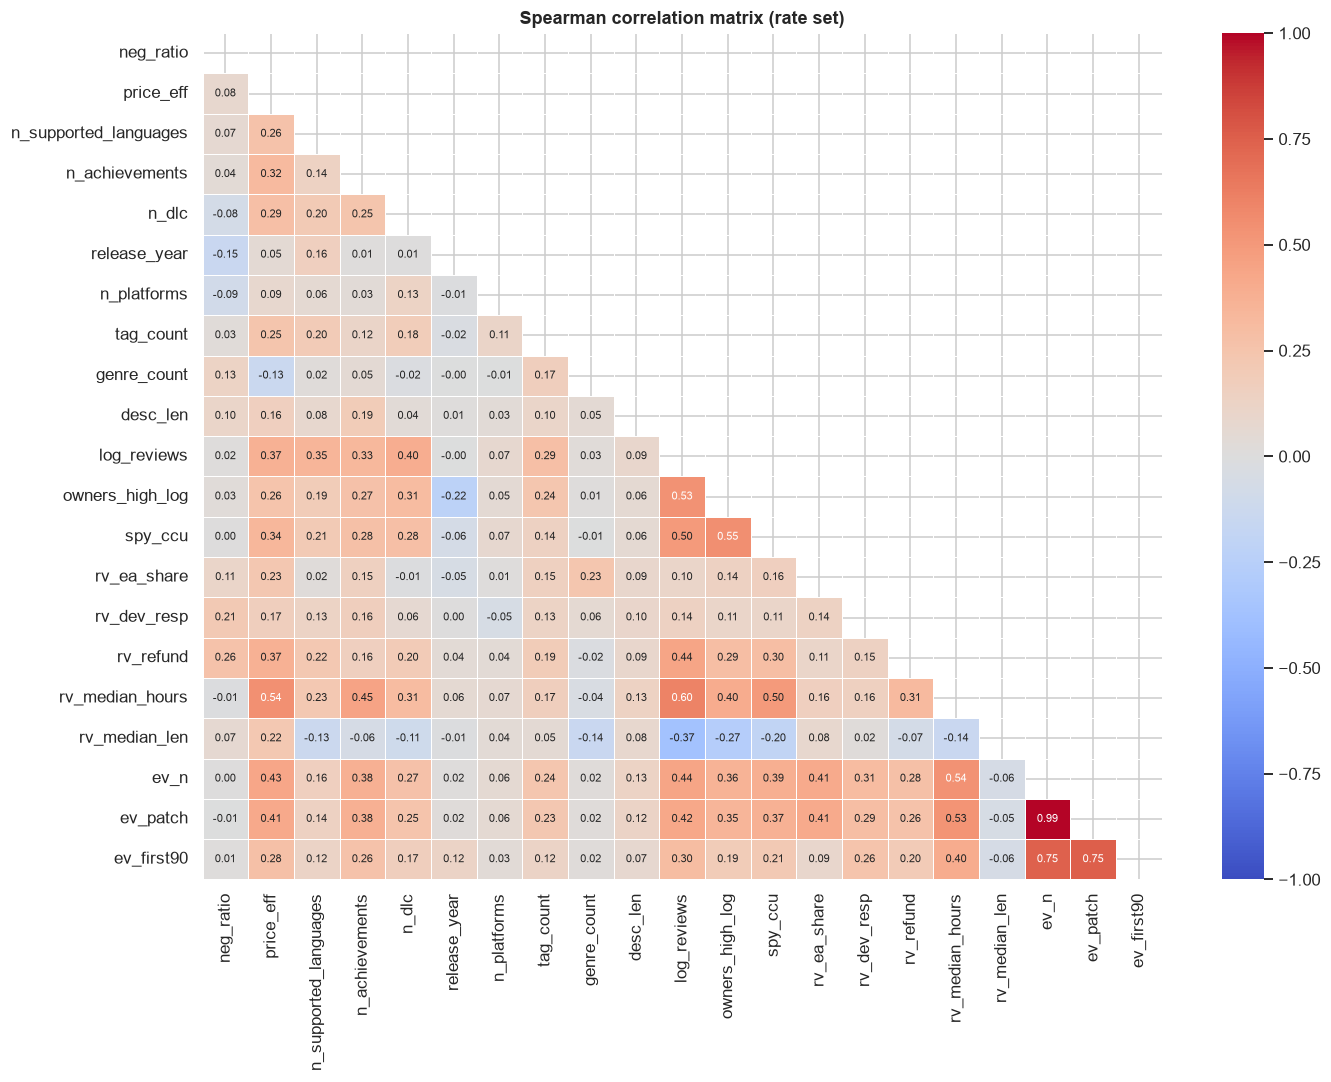

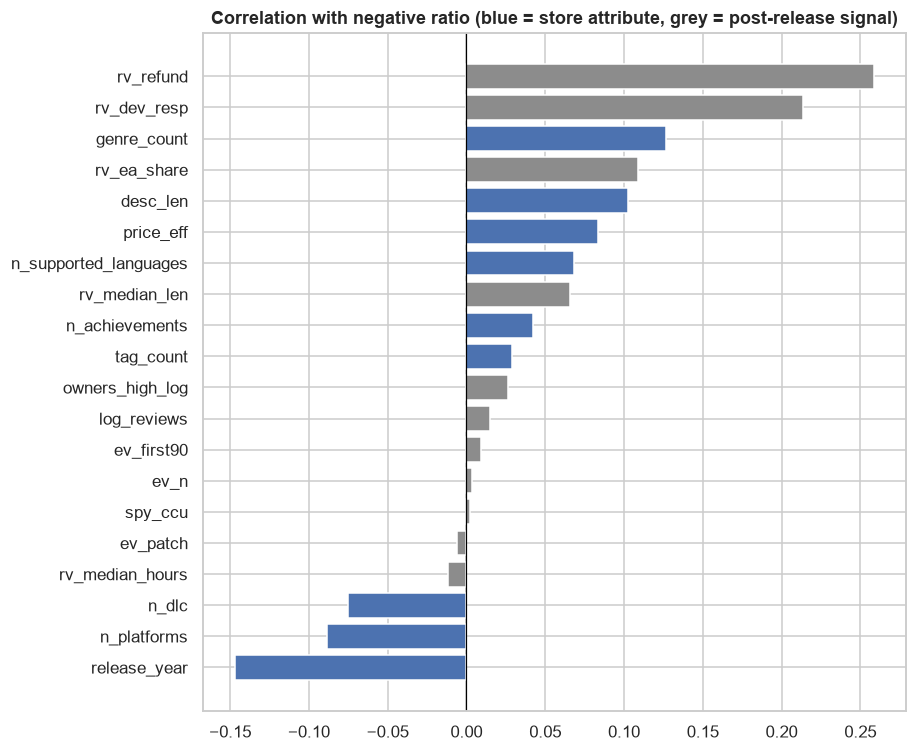

Feature pairs with |rho| >= 0.7 (redundancy candidates):


,feature_a,feature_b,rho
417,ev_patch,ev_n,0.992
439,ev_first90,ev_patch,0.753
438,ev_first90,ev_n,0.745


In [17]:
STORE_ATTR = ["price_eff", "n_supported_languages", "n_achievements", "n_dlc", "release_year", "n_platforms",
              "tag_count", "genre_count", "desc_len"]
POST_RELEASE = ["log_reviews", "owners_high_log", "spy_ccu", "rv_ea_share", "rv_dev_resp", "rv_refund",
                "rv_median_hours", "rv_median_len", "ev_n", "ev_patch", "ev_first90"]
num_cols = ["neg_ratio"] + STORE_ATTR + POST_RELEASE
corr = gr[num_cols].apply(pd.to_numeric, errors="coerce").corr(method="spearman")

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7}, linewidths=0.4, ax=ax)
ax.set_title("Spearman correlation matrix (rate set)")
save("correlation_heatmap", "Spearman correlation matrix of numeric game features and the negative ratio")

target_corr = corr["neg_ratio"].drop("neg_ratio").sort_values()
colors = [BLUE if c in STORE_ATTR else GREY for c in target_corr.index]
fig, ax = plt.subplots(figsize=(8.5, 7))
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Correlation with negative ratio (blue = store attribute, grey = post-release signal)")
save("correlation_with_target", "Spearman correlation of each feature with the negative ratio, split by feature group")

pairs = corr.where(np.tril(np.ones(corr.shape, dtype=bool), k=-1)).stack().rename("rho").reset_index()
pairs.columns = ["feature_a", "feature_b", "rho"]
print("Feature pairs with |rho| >= 0.7 (redundancy candidates):")
display(pairs[pairs.rho.abs() >= 0.7].sort_values("rho", key=abs, ascending=False))

## 10. Feature-engineering diagnostics
Exploratory support for the feature-engineering step (Unit 1: reducing the number of categories in categorical variables, converting categorical variables to numeric form, principal components analysis). These are diagnostics, not the final transformations.

,distinct_values
developers,1930
publishers,1713
genres,12
categories,57
tags,386
price_currency,1
controller_support,1


383 distinct tags; 158 appear on at least 25 games; 79 tags cover 80% of all tag assignments


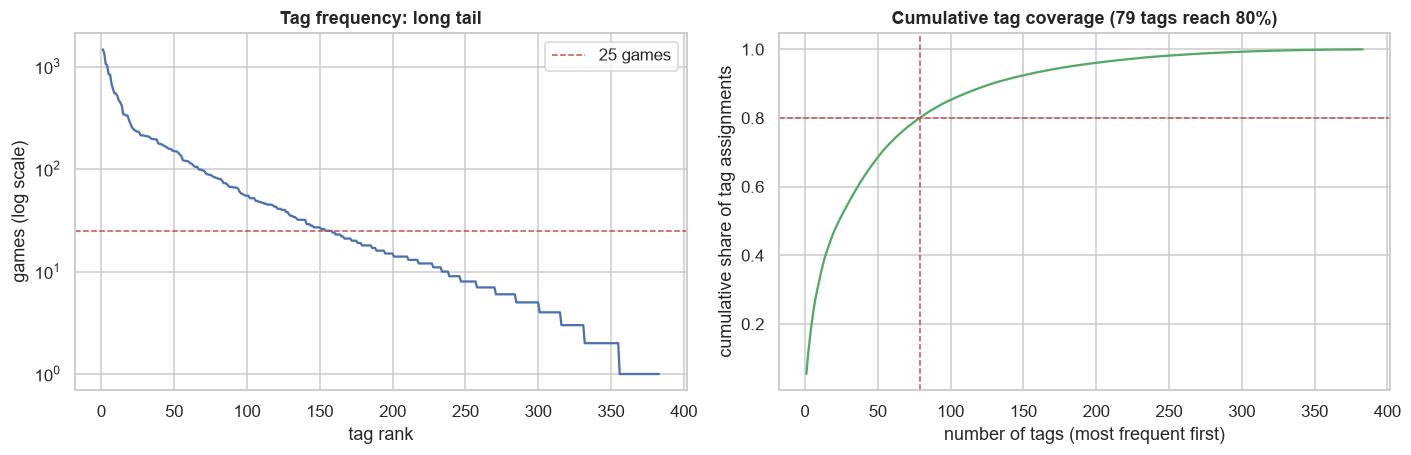

In [18]:
# Cardinality of categorical columns
card = pd.DataFrame({
    "distinct_values": {
        "developers": g.developers.fillna("").str.split(";").explode().str.strip().replace("", np.nan).nunique(),
        "publishers": g.publishers.fillna("").str.split(";").explode().str.strip().replace("", np.nan).nunique(),
        "genres": g.genres.fillna("").str.split(";").explode().str.strip().replace("", np.nan).nunique(),
        "categories": g.categories.fillna("").str.split(";").explode().str.strip().replace("", np.nan).nunique(),
        "tags": g.tags.fillna("").str.split(";").explode().str.strip().replace("", np.nan).nunique(),
        "price_currency": g.price_currency.nunique(),
        "controller_support": g.controller_support.nunique(),
    }
})
display(card)

# Long tail of tags
tag_all = gr.tags.fillna("").str.split(";").explode().str.strip()
tc = tag_all[tag_all != ""].value_counts()
cum = tc.cumsum() / tc.sum()
n80 = int((cum < 0.80).sum() + 1)
n_support = int((tc >= MIN_PAIR_SUPPORT).sum())
print(f"{len(tc)} distinct tags; {n_support} appear on at least {MIN_PAIR_SUPPORT} games; {n80} tags cover 80% of all tag assignments")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
axes[0].plot(range(1, len(tc) + 1), tc.values, color=BLUE); axes[0].set_yscale("log")
axes[0].axhline(MIN_PAIR_SUPPORT, ls="--", c=RED, lw=1, label=f"{MIN_PAIR_SUPPORT} games")
axes[0].set_xlabel("tag rank"); axes[0].set_ylabel("games (log scale)"); axes[0].set_title("Tag frequency: long tail"); axes[0].legend()
axes[1].plot(range(1, len(cum) + 1), cum.values, color=GREEN)
axes[1].axhline(0.8, ls="--", c=RED, lw=1); axes[1].axvline(n80, ls="--", c=RED, lw=1)
axes[1].set_xlabel("number of tags (most frequent first)"); axes[1].set_ylabel("cumulative share of tag assignments")
axes[1].set_title(f"Cumulative tag coverage ({n80} tags reach 80%)")
save("tag_long_tail", "Tag frequency long tail and cumulative coverage (basis for category reduction)")

Components needed for 80% of variance: 8 of 10


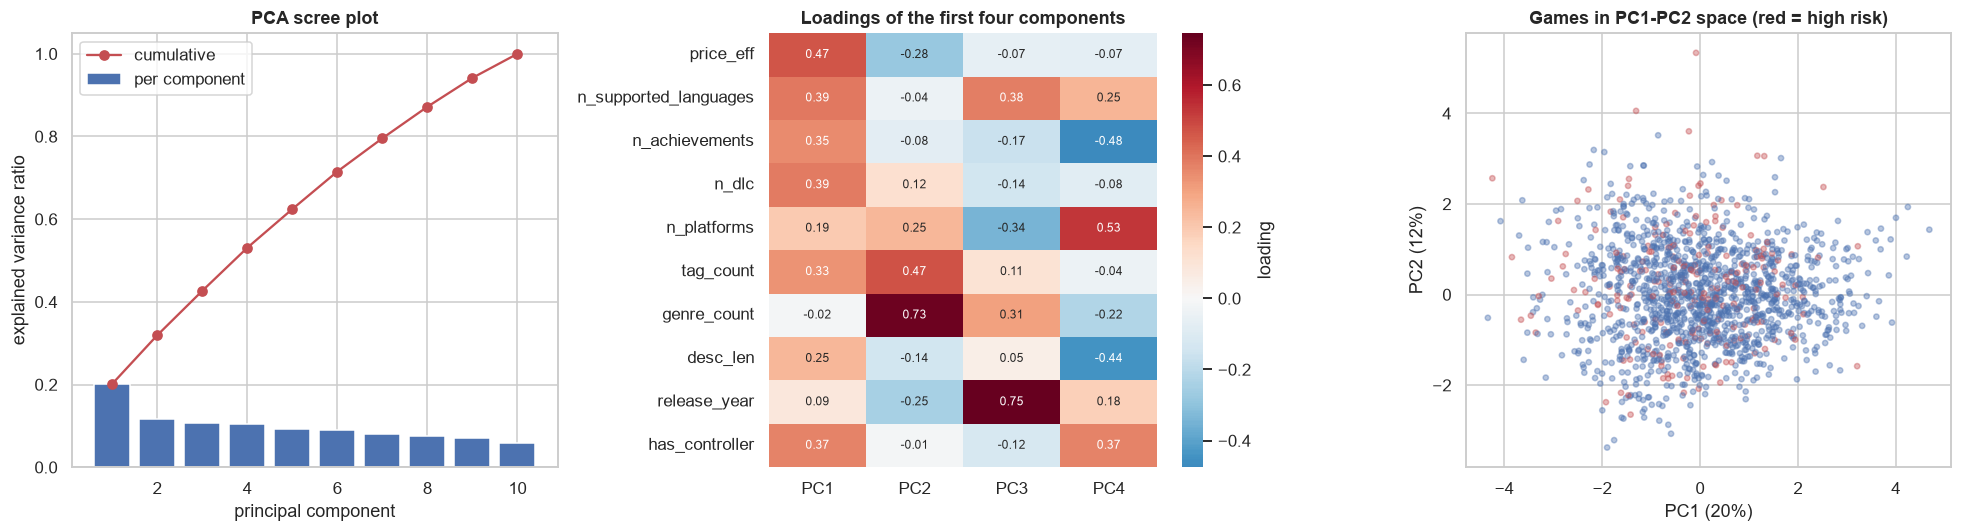

In [19]:
# PCA on store attributes (standardised; skewed counts log-transformed; missing values median-imputed)
pca_df = gr[["price_eff", "n_supported_languages", "n_achievements", "n_dlc", "n_platforms",
             "tag_count", "genre_count", "desc_len", "release_year"]].copy()
pca_df["has_controller"] = gr.has_controller.astype(float)
for c in ["price_eff", "n_supported_languages", "n_achievements", "n_dlc", "desc_len"]:
    pca_df[c] = np.log1p(pca_df[c])
pca_df = pca_df.apply(pd.to_numeric, errors="coerce")
pca_df = pca_df.fillna(pca_df.median())

Xs = StandardScaler().fit_transform(pca_df)
pca = PCA(random_state=RANDOM_STATE).fit(Xs)
evr = pca.explained_variance_ratio_
n80_pc = int(np.searchsorted(np.cumsum(evr), 0.80) + 1)
print(f"Components needed for 80% of variance: {n80_pc} of {len(evr)}")

scores = pca.transform(Xs)
load = pd.DataFrame(pca.components_[:4].T, index=pca_df.columns, columns=[f"PC{i + 1}" for i in range(4)])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(range(1, len(evr) + 1), evr, color=BLUE, label="per component")
axes[0].plot(range(1, len(evr) + 1), np.cumsum(evr), color=RED, marker="o", label="cumulative")
axes[0].set_xlabel("principal component"); axes[0].set_ylabel("explained variance ratio"); axes[0].set_title("PCA scree plot"); axes[0].legend()
sns.heatmap(load, cmap="RdBu_r", center=0, annot=True, fmt=".2f", annot_kws={"size": 8}, ax=axes[1], cbar_kws={"label": "loading"})
axes[1].set_title("Loadings of the first four components")
axes[2].scatter(scores[:, 0], scores[:, 1], c=np.where(gr.high_risk == 1, RED, BLUE), s=12, alpha=0.4)
axes[2].set_xlabel(f"PC1 ({evr[0]:.0%})"); axes[2].set_ylabel(f"PC2 ({evr[1]:.0%})"); axes[2].set_title("Games in PC1-PC2 space (red = high risk)")
save("pca_diagnostics", "PCA scree plot, component loadings and PC1-PC2 projection coloured by risk class")

## 11. Feature combinations associated with reception
Each pair of the 30 most frequent non-generic tags is evaluated when at least `MIN_PAIR_SUPPORT` games carry both. For every pair the high-risk rate is compared with the overall rate using an exact binomial test; p-values are corrected for the number of pairs tested with the Benjamini-Hochberg false-discovery-rate procedure (`q < FDR_ALPHA`). Pairs are ranked conservatively, by the confidence bound nearest to the overall rate, so small samples cannot top the list.

Tag pairs overlap and the tags themselves are correlated, so the procedure controls the false-discovery rate approximately; the results are associations and do not establish that a tag combination causes better or worse reception.

In [20]:
tag_sets = gr.tags.fillna("").str.split(";").apply(lambda L: {t.strip() for t in L if t.strip()} - GENERIC_TAGS)
cnt = Counter(t for s in tag_sets for t in s)
TOP = [t for t, _ in cnt.most_common(30)]
M = pd.DataFrame({t: tag_sets.apply(lambda s, t=t: t in s) for t in TOP})
single_risk = {t: gr.loc[M[t].values, "high_risk"].mean() for t in TOP}

rows = []
for a, b in itertools.combinations(TOP, 2):
    mask = (M[a] & M[b]).values
    n = int(mask.sum())
    if n >= MIN_PAIR_SUPPORT:
        k = int(gr.loc[mask, "high_risk"].sum())
        rows.append({"combo": f"{a} + {b}", "tag_a": a, "tag_b": b, "n_games": n, "k": k, "risk": k / n,
                     "avg_pos_ratio": gr.loc[mask, "pos_ratio"].mean(),
                     "p_value": stats.binomtest(k, n, OVERALL_RISK).pvalue,
                     "risk_reduction_vs_best_single": min(single_risk[a], single_risk[b]) - k / n})
combos = pd.DataFrame(rows)
combos["risk_lo"], combos["risk_hi"] = wilson(combos.k, combos.n_games)
combos["q_value"] = bh_fdr(combos.p_value)
combos["reliable"] = combos.q_value < FDR_ALPHA
combos["direction"] = np.where(combos.risk > OVERALL_RISK, "higher", "lower")
safer = combos[combos.reliable & (combos.direction == "lower")].sort_values("risk_hi")
riskier = combos[combos.reliable & (combos.direction == "higher")].sort_values("risk_lo", ascending=False)
print(f"{len(combos)} pairs evaluated | significant after FDR: {int(combos.reliable.sum())} "
      f"({len(safer)} lower-risk, {len(riskier)} higher-risk) | overall risk {OVERALL_RISK:.1%}")

cols = ["combo", "n_games", "risk", "risk_lo", "risk_hi", "q_value"]
print("Lower-risk combinations (top 15 by upper confidence bound)"); display(safer[cols].head(15))
print("Higher-risk combinations (top 15 by lower confidence bound)"); display(riskier[cols].head(15))

369 pairs evaluated | significant after FDR: 9 (5 lower-risk, 4 higher-risk) | overall risk 14.5%
Lower-risk combinations (top 15 by upper confidence bound)


,combo,n_games,risk,risk_lo,risk_hi,q_value
52,Strategy + Pixel Graphics,186,0.048,0.026,0.089,0.015
9,2D + Deckbuilding,230,0.070,0.043,0.110,0.041
76,Strategy + Turn-Based Strategy,184,0.065,0.038,0.111,0.045
1,2D + Strategy,380,0.084,0.060,0.116,0.041
2,2D + Pixel Graphics,449,0.091,0.068,0.122,0.041


Higher-risk combinations (top 15 by lower confidence bound)


,combo,n_games,risk,risk_lo,risk_hi,q_value
113,RPG + PvE,64,0.328,0.226,0.450,0.041
157,Adventure + 3D,110,0.273,0.198,0.363,0.041
110,RPG + 3D,100,0.270,0.193,0.364,0.045
38,Action + 3D,214,0.234,0.182,0.295,0.041


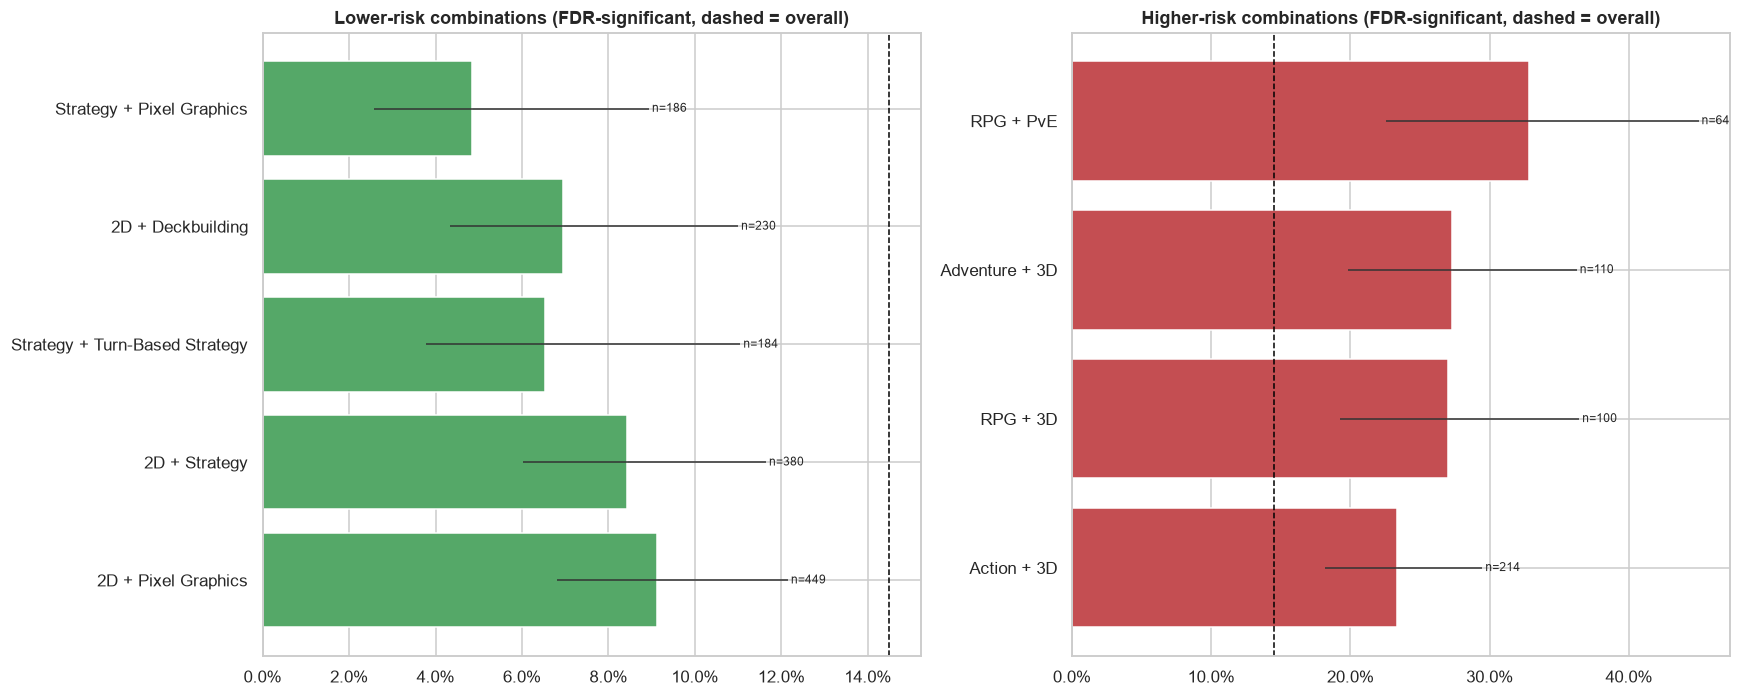

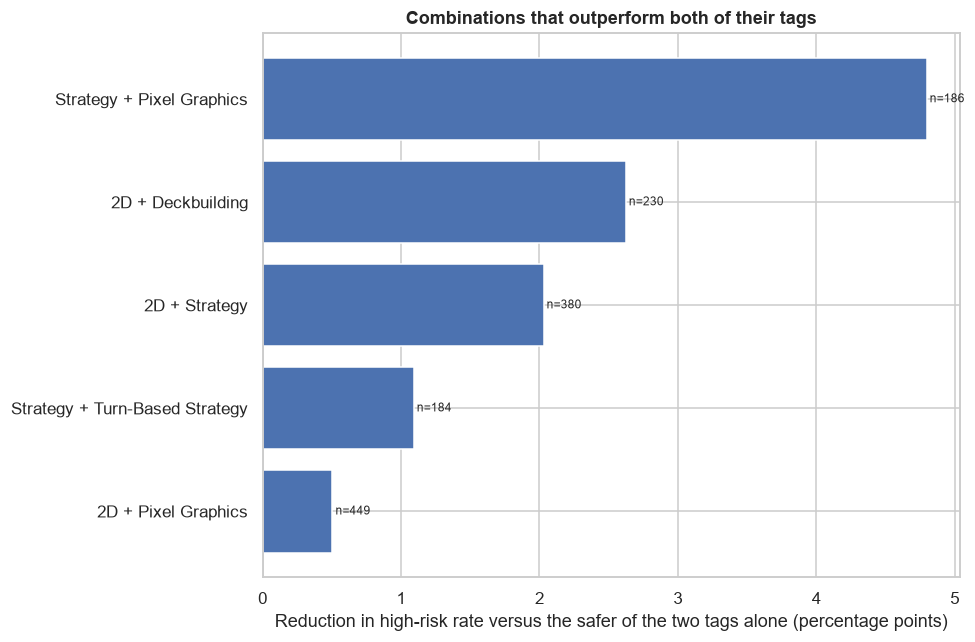

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, d, col, title in [(axes[0], safer.head(12), GREEN, "Lower-risk combinations"), (axes[1], riskier.head(12), RED, "Higher-risk combinations")]:
    d = d.iloc[::-1]
    ax.barh(d.combo, d.risk, color=col, xerr=err(d.risk, d.risk_lo, d.risk_hi), error_kw={"elinewidth": 1, "ecolor": "#333333"})
    ax.axvline(OVERALL_RISK, ls="--", c="black", lw=1)
    for i, (_, r) in enumerate(d.iterrows()):
        ax.text(r.risk_hi, i, f" n={int(r.n_games)}", va="center", fontsize=8)
    ax.set_title(f"{title} (FDR-significant, dashed = overall)"); ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
save("tag_combinations_lower_and_higher_risk", "FDR-significant tag pairs with the lowest and highest high-risk rates, with 95% intervals")

gain = safer.sort_values("risk_reduction_vs_best_single", ascending=False).head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(gain.combo, gain.risk_reduction_vs_best_single * 100, color=BLUE)
for i, (_, r) in enumerate(gain.iterrows()):
    ax.text(r.risk_reduction_vs_best_single * 100, i, f" n={int(r.n_games)}", va="center", fontsize=8)
ax.set_xlabel("Reduction in high-risk rate versus the safer of the two tags alone (percentage points)")
ax.set_title("Combinations that outperform both of their tags")
save("tag_combination_gain", "Lower-risk pairs ranked by improvement over the safer single tag")

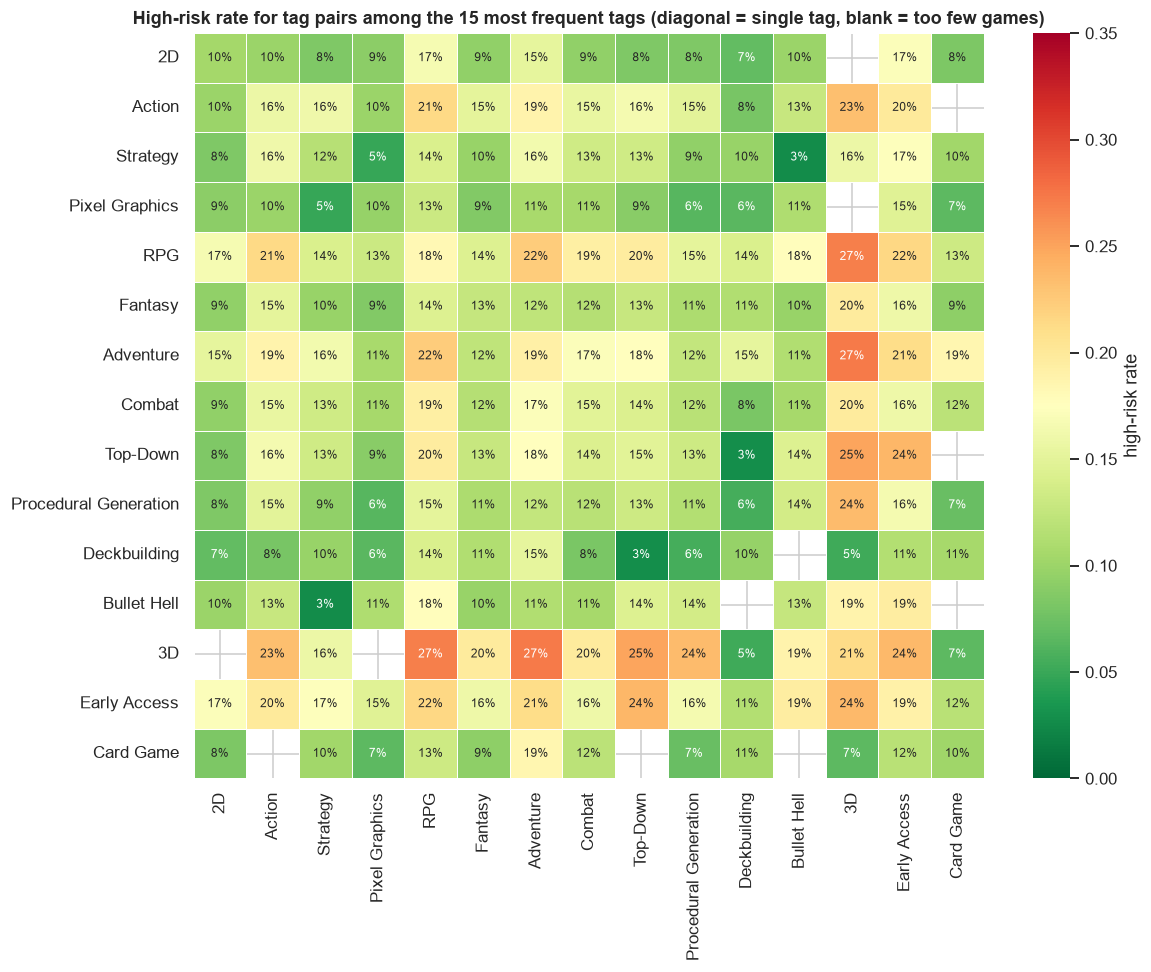

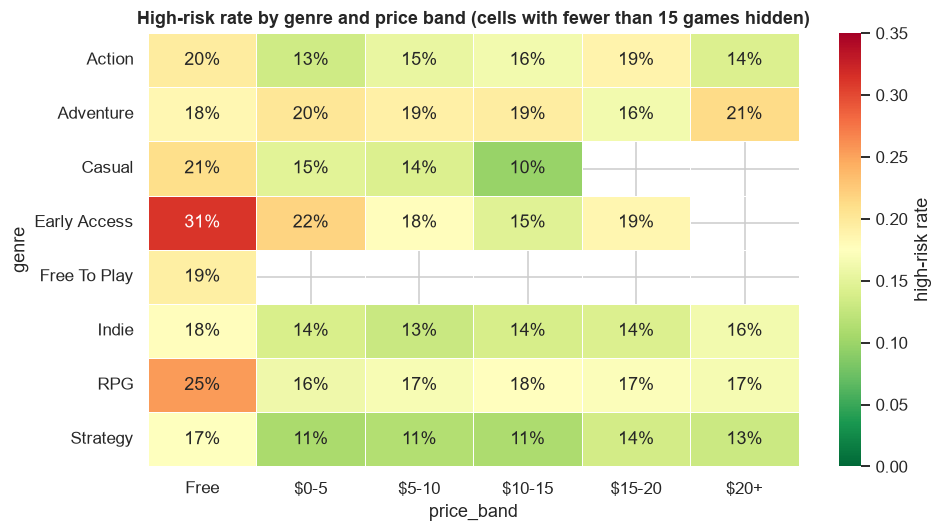

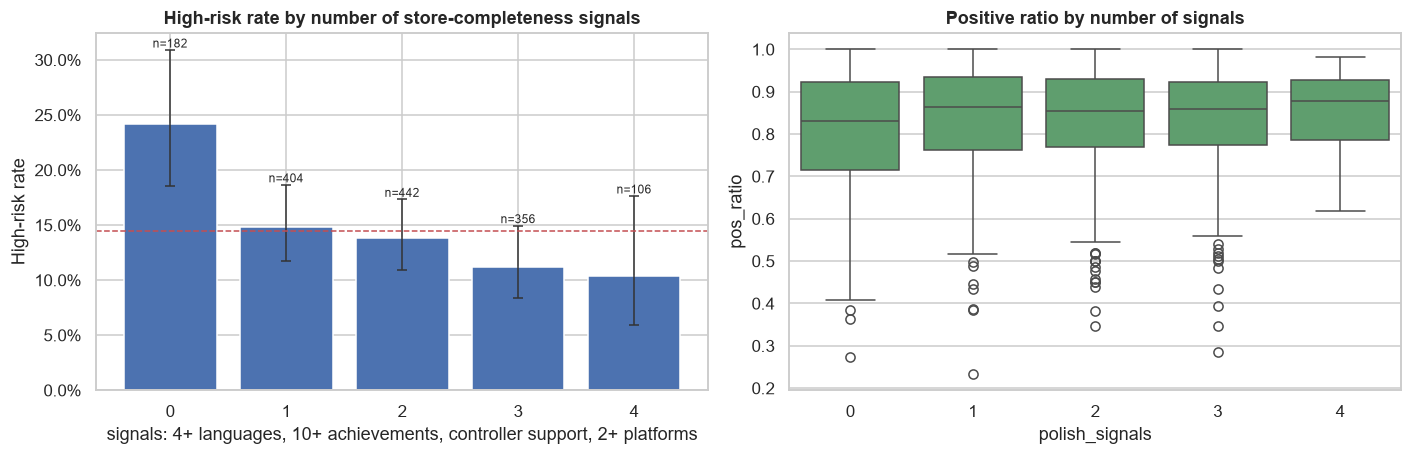

In [22]:
T15 = TOP[:15]
mat = pd.DataFrame(np.nan, index=T15, columns=T15)
for a, b in itertools.combinations(T15, 2):
    mask = (M[a] & M[b]).values
    if mask.sum() >= MIN_PAIR_SUPPORT:
        mat.loc[a, b] = mat.loc[b, a] = gr.loc[mask, "high_risk"].mean()
for t in T15:
    mat.loc[t, t] = single_risk[t]
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(mat, cmap="RdYlGn_r", vmin=0, vmax=0.35, annot=True, fmt=".0%", annot_kws={"size": 8}, linewidths=0.4, ax=ax,
            cbar_kws={"label": "high-risk rate"})
ax.set_title("High-risk rate for tag pairs among the 15 most frequent tags (diagonal = single tag, blank = too few games)")
save("tag_pair_heatmap", "High-risk rate of tag pairs among the 15 most frequent tags")

# Genre x price band
top_genres = genre_stats.head(8).index.tolist()
gg = gr.assign(genre=gr.genres.fillna("").str.split(";")).explode("genre")
gg["genre"] = gg.genre.str.strip()
gg = gg[gg.genre.isin(top_genres)]
piv = gg.pivot_table(index="genre", columns="price_band", values="high_risk", aggfunc="mean", observed=True)
cnt_piv = gg.pivot_table(index="genre", columns="price_band", values="appid", aggfunc="count", observed=True)
piv = piv.where(cnt_piv >= 15)
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(piv, cmap="RdYlGn_r", vmin=0, vmax=0.35, annot=True, fmt=".0%", linewidths=0.4, ax=ax, cbar_kws={"label": "high-risk rate"})
ax.set_title("High-risk rate by genre and price band (cells with fewer than 15 games hidden)")
save("genre_by_price_heatmap", "High-risk rate by genre and price band")

# Cumulative store-quality signals
gr["polish_signals"] = ((gr.n_supported_languages.fillna(0) >= 4).astype(int) + (gr.n_achievements.fillna(0) >= 10).astype(int)
                        + gr.has_controller.astype(int) + (gr.n_platforms >= 2).astype(int))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
risk_by(gr, "polish_signals", axes[0], "High-risk rate by number of store-completeness signals")
axes[0].set_xlabel("signals: 4+ languages, 10+ achievements, controller support, 2+ platforms")
sns.boxplot(data=gr, x="polish_signals", y="pos_ratio", color=GREEN, ax=axes[1]); axes[1].set_title("Positive ratio by number of signals")
save("store_completeness_signals", "High-risk rate and positive ratio by number of store-completeness signals")

## 12. Summary of findings, technical notes and figure index

In [23]:
def extremes(df, col, min_n=30):
    t = df.groupby(col, observed=True).agg(n=("appid", "size"), risk=("high_risk", "mean")).reset_index()
    t = t[t.n >= min_n]
    lo, hi = t.loc[t.risk.idxmin()], t.loc[t.risk.idxmax()]
    return (f"lowest {lo[col]} ({lo.risk:.1%}, n={int(lo.n)}), highest {hi[col]} ({hi.risk:.1%}, n={int(hi.n)})")

def top_labels(st, n=3):
    s = st[st.n >= 50].sort_values("risk")
    return ("lowest: " + ", ".join(f"{i} ({r:.1%})" for i, r in s.risk.head(n).items()) +
            " | highest: " + ", ".join(f"{i} ({r:.1%})" for i, r in s.risk.tail(n)[::-1].items()))

by_year = gr.groupby("release_year").high_risk.mean()
sc = target_corr[[c for c in STORE_ATTR if c in target_corr.index]].sort_values()
pc = target_corr[[c for c in POST_RELEASE if c in target_corr.index]].sort_values()
n3d = int(riskier.head(12).combo.str.contains("3D", regex=False).sum())

lines = [
    f"Target: {OVERALL_RISK:.1%} of {len(gr)} games are high risk (negative ratio >= {HIGH_RISK_THRESHOLD:.0%}); {REV_NEG:.1%} of {len(reviews):,} reviews are negative.",
    f"Price band: {extremes(gr, 'price_band')}.",
    "Release year (high-risk rate): " + ", ".join(f"{y} {r:.1%}" for y, r in by_year.items()) + ".",
    f"Supported languages: {extremes(gr, 'lang_band')}.",
    f"Achievements: {extremes(gr, 'ach_band')}.",
    f"DLC count: {extremes(gr, 'dlc_band')}.",
    f"Genres: {top_labels(genre_stats)}.",
    f"Tags: {top_labels(tag_stats)}.",
    f"Post-release update posts: {extremes(gr, 'ev_band')}.",
    f"Store attributes most correlated with the negative ratio: {sc.index[-1]} ({sc.iloc[-1]:+.2f}) and {sc.index[0]} ({sc.iloc[0]:+.2f}).",
    f"Post-release signals most correlated with the negative ratio: {pc.index[-1]} ({pc.iloc[-1]:+.2f}) and {pc.index[0]} ({pc.iloc[0]:+.2f}).",
    f"Tag pairs: {len(safer)} lower-risk and {len(riskier)} higher-risk pairs survive FDR control; the tag 3D appears in {n3d} of the 12 highest-risk pairs shown.",
    f"Association tests: {int(assoc.significant_fdr.sum())} of {len(assoc)} banded features are significantly associated with risk after FDR (largest Cramer's V: {assoc.loc[assoc.cramers_v.idxmax(), 'feature']}, {assoc.cramers_v.max():.2f}).",
    f"PCA on store attributes: {n80_pc} of {len(evr)} components are needed for 80% of the variance.",
]
for i, l in enumerate(lines, 1):
    print(f"{i:>2}. {l}")

 1. Target: 14.5% of 1490 games are high risk (negative ratio >= 30%); 10.4% of 1,648,387 reviews are negative.
 2. Price band: lowest $5-10 (13.0%, n=432), highest Free (18.4%, n=207).
 3. Release year (high-risk rate): 2022 20.6%, 2023 13.7%, 2024 17.2%, 2025 9.8%.
 4. Supported languages: lowest 13+ (9.3%, n=140), highest 2-3 (15.9%, n=301).
 5. Achievements: lowest 100+ (11.1%, n=45), highest Not listed (21.5%, n=270).
 6. DLC count: lowest 1-2 (7.1%, n=296), highest 0 (16.5%, n=1132).
 7. Genres: lowest: Strategy (12.2%), Indie (14.3%), Casual (15.4%) | highest: Free To Play (19.9%), Early Access (19.3%), Adventure (19.1%).
 8. Tags: lowest: Comedy (1.5%), Old School (3.8%), Twin Stick Shooter (4.5%) | highest: Third Person (29.2%), Mythology (29.1%), Online Co-Op (28.6%).
 9. Post-release update posts: lowest 40+ (9.1%, n=165), highest 0 (19.1%, n=141).
10. Store attributes most correlated with the negative ratio: genre_count (+0.13) and release_year (-0.15).
11. Post-release sig

### Interpretation guidance
- All relationships are **associations** in observational data. They do not show that changing a feature changes reception.
- Effect sizes are small to moderate. Rank correlations with the negative ratio are weak, and differences between bands typically range from a few to roughly ten percentage points of high-risk rate. The clearest signals are concentrated in the high-risk tail rather than spread across the whole distribution.
- **Review volume, owner estimates, concurrent users and review-behaviour aggregates are consequences of reception.** They are useful for description but cannot be used to anticipate risk at launch.
- Release-year differences are confounded with exposure time: recent releases have had less time to accumulate negative reviews.
- Store attributes (price, languages, achievements, DLC, platforms, tags) were captured at the snapshot date, not at launch, so DLC and achievement counts can include post-launch additions.
- Tag combinations are filtered by FDR-controlled tests and ranked by confidence bounds. Pair statistics with few games remain uncertain even when significant.

### Technical notes for downstream work
**Target and sampling**
- The target is `high_risk = (steam_total_negative / steam_total_reviews) >= HIGH_RISK_THRESHOLD`. Any change to the threshold must be applied identically in the modelling notebook.
- Rate comparisons use games with at least `MIN_REVIEWS_FOR_RATE` reviews. The remaining games are retained in the data but have unstable ratios. Document the chosen inclusion rule for modelling.
- Class imbalance is moderate (see section 3); use stratified train/test splits and report precision, recall and PR-AUC in addition to accuracy.

**Leakage**
- Do not use as predictors: `steam_total_reviews`, `steam_total_positive`, `steam_total_negative`, `steam_review_score`, `steam_review_score_desc`, `search_pct_positive`, `search_review_count`, `spy_positive`, `spy_negative`, and every review-derived aggregate (`rv_*`). These encode the outcome directly.
- Treat `spy_owners_*`, `spy_ccu`, `recommendations_total`, `metacritic_score` and `ev_*` as post-release signals; include them only if the model is explicitly a post-launch monitor.

**Data handling**
- Review timestamps are timezone-aware (UTC); event dates are converted to naive timestamps before comparison with `release_date`.
- `n_achievements`, `metacritic_score`, `recommendations_total` and `controller_support` contain structural missingness (absence usually means "not listed"); decide between an explicit indicator and imputation in preprocessing.
- `author_playtime_at_review` is treated as minutes; verify against the data documentation before reporting playtime in hours.
- The reviews table holds a (capped) subset of each game's review history; per-game coverage is shown in section 2. Representativeness of the scraped sample is checked in section 6 (scraped negative share versus Steam-reported ratio).
- `events` contains only `patch` and `sale` event types and is dominated by patches.

**Feature engineering suggestions**
- The tag vocabulary has a long tail (section 10). Keep tags above a support threshold as multi-hot features and group the rest into an "other" bucket.
- High-risk-associated tags (for example 3D, Survival, Early Access, PvE) and low-risk-associated tags (turn-based, deckbuilding, pixel graphics) are candidate features and interaction terms; test interactions for out-of-sample benefit instead of selecting them on the full data.
- Log-transform skewed counts (price, languages, achievements, DLC) before linear or distance-based models.
- Correlated feature pairs are listed in section 9; the PCA in section 10 quantifies the redundancy among the numeric store attributes.

**Reproducibility**
- Settings are defined in section 1; `RANDOM_STATE` fixes the sampling used for plots and PCA.
- Figures are written to `figures/eda/` in execution order; the folder is cleared at the start of each full run.

In [24]:
fig_index = pd.DataFrame(FIG_REGISTRY)
fig_index.index = fig_index.index + 1
with pd.option_context("display.max_colwidth", 140):
    display(fig_index)

,figure,description
1,01_missing_values_games.png,Share of missing values per column in the games table
2,02_review_coverage.png,Share of each game's total review history present in the reviews table
3,03_target_definition.png,"Negative-ratio distribution, target class balance and Steam review label counts"
4,04_negative_ratio_vs_review_volume.png,Negative ratio against review volume (funnel shape shows small-sample noise)
5,05_univariate_numeric.png,"Distributions of review volume, price, release year, languages, achievements and owner estimate"
6,06_univariate_genres_tags_categories.png,"Most frequent genres, tags and store categories"
7,07_univariate_platform_price_controller.png,"Platform support, free versus paid, and controller support"
8,08_univariate_owner_ranges.png,Number of games per estimated owner range
9,09_top_developers.png,Developers with the most games in the dataset
10,10_risk_by_game_features.png,"High-risk rate by price, release year, languages, achievements, review volume and DLC count"
